# Two-Crack Stepover Cascade — Dynamic Triggering Showcase

Two **curved** faults in an extensional stepover.  Crack **A** (master) is
loaded to 99 % of its static strength and seeded with a small nucleation
patch — it ruptures at $t = 0$.  Crack **B** (victim) is at 92 % of its
static strength: stable on its own, reactivated only when the radiated
stress field from A reaches it.

Showcase points
* Neither crack is mesh-aligned — the SBM surrogate facets stair-step through
  unstructured triangles.
* Local strike angle varies along each arc, so $\sigma_N(s)$ and $\tau(s)$
  vary; the rupture front visibly accelerates / decelerates as the fault
  orientation changes along the curve.
* Cascade triggering produces a two-stage rupture pattern in the bulk
  velocity movie and a delayed second wedge in the per-crack arc–time
  diagram.

Built on top of `embedded_crack_mc_sliding.ipynb`, reusing its contact and
solver infrastructure; only geometry, prestress, and visualisation differ.


In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '6')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder, MaterialParams
from poroelasticity.config import ScaleFactors as _ScaleFactors
from poroelasticity.nondimensionalise import compute_dimensionless_params as _compute_ndp
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.projected_radau_contact import build_projected_radau_contact


print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')


solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [2]:
# =============================================================================
# Wave-clock nondim override (notebook-local; no library code changes)
# =============================================================================
# When alpha != 0 the library default selects the *consolidation* clock
#     T = L^2 * beta / C
# which makes rho_d ~ (T_w / T_d)^2 collapse to a tiny perturbation and
# turns the dynamic system into a stiff DAE.  For poroelastoDYNAMICS
# (waves + Biot coupling active simultaneously) we want the *wave* clock
#     T = L * sqrt(rho / Mmod)
# with alpha kept as a coupling parameter (NOT normalized to 1).
#
# This cell is RE-RUN SAFE: it caches the pristine library function on
# the cgporoelastostatics module the first time, so re-running the cell
# always patches the original (not a previously-installed override).
# Set `_USE_WAVE_CLOCK_OVERRIDE = False` to revert to the library default.

import dataclasses as _dc
import poroelasticity.cgporoelastostatics as _cgmod
import poroelasticity.nondimensionalise as _nondim_mod

_USE_WAVE_CLOCK_OVERRIDE = True

# Idempotent capture of the pristine library function (survives kernel re-runs)
if not hasattr(_cgmod, "_pristine_compute_dimensionless_params"):
    _cgmod._pristine_compute_dimensionless_params = _nondim_mod.compute_dimensionless_params
_orig_compute_ndp = _cgmod._pristine_compute_dimensionless_params


def _wave_clock_ndp(material, scales, crack_model=None,
                    bulk_viscosity=None, dim=2, P_scale_override=None):
    """Force wave-clock T_scale even when alpha != 0.

    Calls the library's alpha=0 path (which IS wave clock when rho > 0),
    then re-derives only the alpha-dependent fields:
        alpha_d = alpha            (kept; not normalised to 1)
        C_d     = C * T_w / (beta * L^2)
        P_scale = alpha * eps / beta
        Q_scale = beta * P_scale / T_w  =  alpha * eps / T_w
        T_robin_d rescaled with the new P_scale
    All other fields (mu_d, lam_d, T_scale, rho_d=1, mu_v_d, eta_n_d,
    eta_t_d, fracture_perm_d, k_n_d, k_t_d, U_scale, Sigma_scale,
    Mmod_scale, VL_scale, reference_aperture_d) are inherited unchanged
    from the alpha=0 wave-clock baseline.
    """
    if material.alpha == 0.0:
        return _orig_compute_ndp(
            material, scales,
            crack_model=crack_model, bulk_viscosity=bulk_viscosity,
            dim=dim, P_scale_override=P_scale_override,
        )

    # Step 1: wave-clock baseline by faking alpha = 0
    mat0 = _dc.replace(material, alpha=0.0)
    ndp0 = _orig_compute_ndp(
        mat0, scales,
        crack_model=crack_model, bulk_viscosity=bulk_viscosity, dim=dim,
    )

    # Step 2: re-derive alpha-dependent fields
    alpha = material.alpha
    beta  = material.beta
    C     = material.C
    L     = scales.L
    eps   = scales.eps
    T_w   = ndp0.T_scale
    Mmod  = ndp0.Mmod_scale

    P_scale_new = alpha * eps / beta
    Q_scale_new = beta * P_scale_new / T_w
    C_d_new     = C * T_w / (beta * L ** 2) if C > 0 else 0.0
    if crack_model is not None and getattr(crack_model, "T", 0.0):
        T_robin_d_new = crack_model.T * T_w * P_scale_new / (Mmod * L * eps)
    else:
        T_robin_d_new = ndp0.T_robin_d

    return _dc.replace(
        ndp0,
        alpha_d=alpha,
        C_d=C_d_new,
        P_scale=P_scale_new,
        Q_scale=Q_scale_new,
        T_robin_d=T_robin_d_new,
    )


# Apply or revert (always patches to a known-good source, never to a previous override)
if _USE_WAVE_CLOCK_OVERRIDE:
    _cgmod.compute_dimensionless_params = _wave_clock_ndp
    _compute_ndp = _wave_clock_ndp
    print("[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)")
else:
    _cgmod.compute_dimensionless_params = _orig_compute_ndp
    _compute_ndp = _orig_compute_ndp
    print("[wave-clock override] DISABLED -- library default (alpha != 0 => diffusion clock)")

[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)


In [3]:
# =====================================================================
# USER INPUTS — all in PHYSICAL units.
# SCALE_L and SCALE_EPS are nondim choices only; changing them must NOT
# change the physics, only the magnitude of internal dimensionless arrays.
# =====================================================================

# --- Output profile -------------------------------------------------------
# Keep the original solve/physics defaults, but skip expensive dashboard and
# movie-frame rendering while iterating on the figure snapshot.
FAST_OUTPUT_MODE = True

# --- Solve profiling ------------------------------------------------------
# Toggle this on to wrap the slip-weakening solve in cProfile.  The solve
# physics are unchanged; only profiling output and optional stats dumping
# are added around the call to solve_ivp_ns.
PROFILE_SW_SOLVE = True
PROFILE_SW_TOP_N = 40
PROFILE_SW_SORT_KEYS = ('cumtime', 'tottime')
PROFILE_SW_STATS_PATH = None  # e.g. 'images/two_crack_stepover_sw_solve.prof'

# --- Material -------------------------------------------------------------
NU          = 0.3
G_SHEAR     = 10e3               # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0
BETA_FLUID  = 8.5e-5             # 1/MPa
ETA_FLUID   = 2.0e-18 / 3600.0   # MPa·s
K_PERM      = 1.0e-15 * 1.0e-6   # m²
DENSITY_PHYS = 2.7e3             # MPa·s²/km² (km geometry; ρ_SI [kg/m³])
BULK_DAMPING_FRACTION = 5e-4*0     # 0 = undamped, ~1 = critical, > 1 = over

# --- Geometry (PHYSICAL lengths) ------------------------------------------
# These are passed straight to CrackMeshBuilder; CGPoroelastostatics divides
# by SCALE_L internally (mesh.scaled(1/L)) to obtain the dimensionless mesh.
XMIN, XMAX = 0.0, 20.0
YMIN, YMAX = 0.0, 20.0
N_ELEM     = 14

# --- Mesh type ----------------------------------------------------------
# 'tri'  -> MeshTri.init_tensor  + ElementTriP1 / ElementTriP1Bubble
# 'quad' -> MeshQuad.init_tensor + ElementQuad1 / ElementQuad1Bubble
MESH_TYPE  = 'quad'

CRACK_LENGTH = 6.0
CRACK_X0     = 10.0#0.5 * (XMIN + XMAX)
CRACK_Y0     = 10.0#0.5 * (YMIN + YMAX)

# --- Loading (physical) ---------------------------------------------------
SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 50.0                  # MPa
MU = 0.6                            # static friction (matches slip-weakening μ_static)

# --- Crack hydraulic interface --------------------------------------------
CRACK_T_ROBIN = 0.0
CRACK_MODEL_PARAMS = {'T': CRACK_T_ROBIN, 'tangential_flow': False}

# --- SBM master toggle ---------------------------------------------------
# Flip USE_SBM=True to switch from conforming to shifted-interface mode.
USE_SBM               = True
CONFORMING_CRACK_MESH = not USE_SBM
INCLUDE_SBM           = False
INCLUDE_TAYLOR        = True       # trial-side Taylor (kinematic)
INCLUDE_TAYLOR_TEST   = False       # test-side Taylor (G_u adjoint)
INCLUDE_HESSIAN       = False         # second-order, leave off

# --- Time (physical seconds) ----------------------------------------------
TMAX_PHYS = 6.0     # seconds  (~4.6 nondim, typical earthquake duration)
H_PHYS    = 2.8e-1   # seconds  (~4e-4 nondim, fine for adaptive h0)

# --- Nondim choice (must NOT change physics) ------------------------------
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

# --- Domain refinement knob (BOX_SCALE > 1: enlarge box, keep crack length) ---
BOX_SCALE = 1.0
XMAX *= BOX_SCALE
YMAX *= BOX_SCALE
CRACK_X0 = 0.5 * (XMIN + XMAX)
CRACK_Y0 = 0.5 * (YMIN + YMAX)
N_ELEM   = max(int(round(N_ELEM * BOX_SCALE)), N_ELEM)

# =====================================================================
# DERIVED QUANTITIES — recomputed on every run, do not edit.
# =====================================================================

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)
MATERIAL = MaterialParams(
    mu=MU_LAME, lam=LAM, alpha=ALPHA_BIOT,
    beta=BETA_FLUID, C=K_PERM / ETA_FLUID,
    rho=DENSITY_PHYS,
)
Mmod = LAM + 2 * MU_LAME
Sigma_scale = Mmod * SCALE_EPS
T_scale = _compute_ndp(MATERIAL, _ScaleFactors(L=SCALE_L, eps=SCALE_EPS)).T_scale
BULK_MU_V  = BULK_DAMPING_FRACTION * MU_LAME * T_scale
BULK_LAM_V = BULK_DAMPING_FRACTION * LAM     * T_scale

# Time: dimensionless τ = t_phys / T_scale
TMAX    = TMAX_PHYS / T_scale
H_FIXED = H_PHYS    / T_scale

# Output unit conversions (multiply dimensionless field by these to get physical).
LEN_UNIT_TO_PHYS    = SCALE_L              # x_phys [m]   = x_d * LEN_UNIT_TO_PHYS
DISP_UNIT_TO_PHYS   = SCALE_L * SCALE_EPS  # u_phys [m]   = u_d * DISP_UNIT_TO_PHYS
TIME_UNIT_TO_PHYS   = T_scale              # t_phys [s]   = t_d * TIME_UNIT_TO_PHYS
STRESS_UNIT_TO_PHYS = Sigma_scale          # σ_phys [MPa] = σ_d * STRESS_UNIT_TO_PHYS

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

print(f"Output profile: FAST_OUTPUT_MODE={FAST_OUTPUT_MODE}")
print(f"Domain (PHYS):  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack  (PHYS):  centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e} MPa·s, bulk_lam_v={BULK_LAM_V:.1e} MPa·s")
print(f"Hydraulic crack: Robin T = {CRACK_T_ROBIN}  (0 ⇒ sealed)")
print(f"SBM:     USE_SBM={USE_SBM}, conforming={CONFORMING_CRACK_MESH}, taylor={INCLUDE_TAYLOR}, taylor_test={INCLUDE_TAYLOR_TEST}, sbm={INCLUDE_SBM}, hessian={INCLUDE_HESSIAN}")
print(f"Coupling: lumped_coupling='consistent', taylor_method='nodal'")
print(f"Nondim:  Mmod={Mmod:.0f} MPa, Σ_scale={Sigma_scale:.1f} MPa, T_scale={T_scale:.3e} s")
print(f"Time:    TMAX_PHYS={TMAX_PHYS:.3e} s, H_PHYS={H_PHYS:.3e} s  "
      f"(dimensionless: tmax={TMAX:.3g}, h={H_FIXED:.3g})")

# --- Loading mode ---------------------------------------------------------
LOADING_MODE    = 'prestress'   # 'prestress' | 'displacement'
TOP_COMPRESSION = 0.1            # m  (used only when LOADING_MODE == 'displacement')
T_LOAD          = TMAX           # ramp duration (dimensionless)

def make_bc():
    """Build the BC dict for the active LOADING_MODE."""
    dp_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    if LOADING_MODE == 'prestress':
        return {
            'dp_rate': dp_rate,
        }
    if LOADING_MODE == 'displacement':
        return {
            'v1': {'bottom': 0.0},
            'v2': {'bottom': 0.0},
            'v2_rate': {'top': -TOP_COMPRESSION / T_LOAD},
            'dp_rate': dp_rate,
        }
    raise ValueError(f"unknown LOADING_MODE {LOADING_MODE!r}")

def prestress_offsets(sigma_N_phys, tau_phys):
    """Return (sigma_N, tau) used as Mohr offsets s0, w0 (physical units)."""
    if LOADING_MODE == 'prestress':
        return sigma_N_phys, tau_phys
    return 0.0, 0.0

print(f"LOADING_MODE = {LOADING_MODE!r};  top compression = {TOP_COMPRESSION} m over T_LOAD = {T_LOAD}")


# --- Density convention (READ ME) -----------------------------------------
print(f"physical density: DENSITY_PHYS = {DENSITY_PHYS:.3g} (MPa-consistent units); "
      f"library will compute ρ_d via ρ·L²/(T²·Mmod)")

RAMP_HOLD_AFTER = True

def make_hold_bc(top_displacement_phys):
    """Phase-2 BC: pin top to a fixed displacement (m), no rate."""
    return {
        'v1': {'bottom': 0.0},
        'v2': {'bottom': 0.0, 'top': float(top_displacement_phys)},
        'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
    }

# --- Adaptive integrator constants ---------------------------------------
ADAPTIVE_RTOL  = 1.0e-3
ADAPTIVE_ATOL  = 1.0e-6
ADAPTIVE_H_MIN = 1.0e-5
ADAPTIVE_H_MAX = TMAX/10
H0_ADAPTIVE    = H_FIXED
SOLVER_VERBOSE = True #not FAST_OUTPUT_MODE

# --- Lysmer-Kuhlemeyer absorbing boundary (prestress mode only) -----------
USE_LYSMER  = (LOADING_MODE == 'prestress')
USE_WINKLER = False #(LOADING_MODE == 'prestress')
LYSMER_AP   = 1.0
LYSMER_AS   = 1.0
WINKLER_BP = 1.0    # Winkler P-direction multiplier (kappa_n = b_p Mmod / L_box)
WINKLER_BS = 1.0    # Winkler S-direction multiplier (kappa_t = b_s G    / L_box)


def build_lysmer_damping(poro, a_p=None, a_s=None):
    """Lysmer absorbing-boundary damping matrix in DIMENSIONLESS units (Nu × Nu)."""
    from skfem import FacetBasis, BilinearForm
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS

    E_phys, nu_phys = E_YOUNG, NU
    rho_phys = MATERIAL.rho
    Vp_phys = np.sqrt(E_phys * (1.0 - nu_phys)
                      / ((1.0 + nu_phys) * (1.0 - 2.0 * nu_phys) * rho_phys))
    Vs_phys = np.sqrt(E_phys / (2.0 * (1.0 + nu_phys) * rho_phys))

    L_scale = SCALE_L
    T_scale_loc = _compute_ndp(MATERIAL, _ScaleFactors(L=L_scale, eps=SCALE_EPS)).T_scale
    Vp_d = Vp_phys * T_scale_loc / L_scale
    Vs_d = Vs_phys * T_scale_loc / L_scale

    rho_d = float(poro.rho_d)
    c_n = a_p * rho_d * Vp_d
    c_t = a_s * rho_d * Vs_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def lysmer_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return c_n * u_n * v_n + c_t * (u_tx * v_tx + u_ty * v_ty)

    return lysmer_form.assemble(fb)


def lysmer_descriptor_block(poro, n_phys, n_base, a_p=None, a_s=None):
    """C_lysmer (Nu × Nu) embedded as an n_phys × n_phys sparse matrix."""
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS
    C_l = build_lysmer_damping(poro, a_p=a_p, a_s=a_s).tocsr()
    Nu = C_l.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Lysmer block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    Z_top = sp.csr_matrix((n_base, n_phys))
    Z_left = sp.csr_matrix((Nu, n_base))
    bottom = sp.hstack([Z_left, C_l], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_winkler_stiffness(poro, b_p=None, b_s=None):
    """Winkler boundary spring matrix in DIMENSIONLESS units (Nu × Nu).

    Static stiffness analogue of the Lysmer dashpot.  Normal direction
    uses k_n = b_p · Mmod / L_box, tangential k_t = b_s · G / L_box.
    """
    from skfem import FacetBasis, BilinearForm
    if b_p is None: b_p = WINKLER_BP
    if b_s is None: b_s = WINKLER_BS

    L_box_d = max(XMAX - XMIN, YMAX - YMIN) / SCALE_L
    Mmod_d  = 1.0
    mu_d    = MU_LAME / Mmod
    k_n     = b_p * Mmod_d / L_box_d
    k_t     = b_s * mu_d   / L_box_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def winkler_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return k_n * u_n * v_n + k_t * (u_tx * v_tx + u_ty * v_ty)

    return winkler_form.assemble(fb)


def winkler_descriptor_block(poro, n_phys, n_base, u_state_indices, b_p=None, b_s=None):
    """K_winkler scattered into displacement columns of an n_phys × n_phys block."""
    K_w = build_winkler_stiffness(poro, b_p=b_p, b_s=b_s).tocsr()
    Nu = K_w.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Winkler block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    if u_state_indices.size != Nu:
        raise ValueError(f"u_state_indices size {u_state_indices.size} != Nu {Nu}")
    rows, cols, vals = sp.find(K_w)
    K_w_in_z = sp.csr_matrix(
        (vals, (rows, u_state_indices[cols])),
        shape=(Nu, n_base),
    )
    Z_top   = sp.csr_matrix((n_base, n_phys))
    Z_right = sp.csr_matrix((Nu, Nu))
    bottom  = sp.hstack([K_w_in_z, Z_right], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_per_block_tolerances(cs_obj, poro_obj, *, n_react=0, n_slip=0):
    """Per-DOF (atol_arr, nl_atol_arr) using poro.get_scales().

    Block layout for rotated CG with velocity dynamics:
       0 pb (BULK p), 1 ub (BULK u),
       2 avgp, 3 jmpp,
       4 avgu_n, 5 avgu_t, 6 jmpu_n, 7 jmpu_t,
       8 lam_q,
       9 avg_ls_n, 10 avg_ls_t, 11 jmp_ls_n, 12 jmp_ls_t,
       13 vel(ub), 14 vel(avgu_n), 15 vel(avgu_t), 16 vel(jmpu_n), 17 vel(jmpu_t),
       (18 slip if n_slip>0), (last) reactions if n_react>0.
    Pattern: pressure 1e-6 / P_sc, displacement 1e-9 / U_sc; interface
    pressure tightened by 1e-3 (atol) / 1e-4 (nl_atol); interface displacement
    same as bulk for atol, ×1e-1 for nl_atol.
    """
    T_sc, U_sc, P_sc, Sigma_sc, Mmod_sc, Q_sc, VL_sc = poro_obj.get_scales()

    atol_p = 1e-6 / P_sc
    atol_u = 1e-9 / U_sc
    nl_atol_p = 1e-6 / P_sc
    nl_atol_u = 1e-9 / U_sc
    atol_react = 1e-9 / Sigma_sc
    atol_slip  = 1e-12 / U_sc

    block_atol = [
        atol_p, atol_u,
        atol_p * 1e-3, atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_u,
        atol_u, atol_u, atol_u, atol_u,
    ]
    block_nl_atol = [
        nl_atol_p, nl_atol_u,
        nl_atol_p * 1e-4, nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_u,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
    ]

    if n_slip > 0:
        block_atol.append(atol_slip)
        block_nl_atol.append(atol_slip)
    if n_react > 0:
        block_atol.append(atol_react)
        block_nl_atol.append(atol_react)

    if len(block_atol) != len(cs_obj.component_slices):
        raise ValueError(
            f"block count mismatch: cs has {len(cs_obj.component_slices)} blocks, "
            f"helper provides {len(block_atol)}"
        )

    n_total = int(cs_obj.y0.size)
    atol_arr = np.empty(n_total, dtype=float)
    nl_atol_arr = np.empty(n_total, dtype=float)
    for sl, ablk, nblk in zip(cs_obj.component_slices, block_atol, block_nl_atol):
        atol_arr[sl] = ablk
        nl_atol_arr[sl] = nblk
    return atol_arr, nl_atol_arr

print(f"USE_LYSMER = {USE_LYSMER}  (a_p={LYSMER_AP}, a_s={LYSMER_AS})")
print(f"USE_WINKLER = {USE_WINKLER}  (b_p={WINKLER_BP}, b_s={WINKLER_BS})")

# --- Warm-start helper: Coulomb-cone projection of the prestress offset --
def coulomb_cone_warm_start(s0_arr, w0_arr, mu):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu = float(mu)
    inv = 1.0 / (1.0 + mu * mu)
    out = np.zeros(2 * s0_arr.size)
    for k in range(s0_arr.size):
        sN, w = float(s0_arr[k]), float(w0_arr[k])
        aw = abs(w)
        if sN >= 0.0 and aw <= mu * sN:
            r_n_p, r_t_p = sN, w
        elif mu * sN + aw <= 0.0:
            r_n_p, r_t_p = 0.0, 0.0
        else:
            r_n_p = max((sN + mu * aw) * inv, 0.0)
            r_t_p = mu * r_n_p * (1.0 if w >= 0 else -1.0)
        out[2 * k]     = r_n_p - sN
        out[2 * k + 1] = r_t_p - w
    return out

CONTACT_LAW = 'soc_fb' #'soc_fb' ,'fischer_burmeister'
print(f"contact_law = {CONTACT_LAW!r}")


Output profile: FAST_OUTPUT_MODE=True
Domain (PHYS):  [0.0,20.0] × [0.0,20.0],  N_ELEM = 14
Crack  (PHYS):  centre=(10.0,10.0), length=6.0
Loading: σ_right=10.0, σ_top=50.0  →  σ₁=50.0, σ₃=10.0
Friction: μ = 0.6
Damping: bulk_mu_v=0.0e+00 MPa·s, bulk_lam_v=0.0e+00 MPa·s
Hydraulic crack: Robin T = 0.0  (0 ⇒ sealed)
SBM:     USE_SBM=True, conforming=False, taylor=True, taylor_test=False, sbm=False, hessian=False
Coupling: lumped_coupling='consistent', taylor_method='nodal'
Nondim:  Mmod=35000 MPa, Σ_scale=35.0 MPa, T_scale=2.777e-01 s
Time:    TMAX_PHYS=6.000e+00 s, H_PHYS=2.800e-01 s  (dimensionless: tmax=21.6, h=1.01)
LOADING_MODE = 'prestress';  top compression = 0.1 m over T_LOAD = 21.602468994692867
physical density: DENSITY_PHYS = 2.7e+03 (MPa-consistent units); library will compute ρ_d via ρ·L²/(T²·Mmod)
USE_LYSMER = True  (a_p=1.0, a_s=1.0)
USE_WINKLER = False  (b_p=1.0, b_s=1.0)
contact_law = 'soc_fb'


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [4]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(60)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit  = 29.52° (failure plane angle)
Failure zone: [40.74°, 80.23°]
φ = arctan(μ) = 30.96°

Locked test  (θ = 20° < θ_onset = 40.7°):
  σ_N = 45.32,  τ = 12.86,  μσ_N = 27.19
  |τ|/μσ_N = 0.4728  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 60° ∈ failure zone):
  σ_N = 20.00,  τ = 17.32,  μσ_N = 12.00
  |τ|/μσ_N = 1.4434  (> 1 → sliding)
  crack_theta = 30.0°


## 3. Two-arc fault geometry

Each fault is a parabolic arc parameterised by $X(t) = (1-t)\,P_1 + t\,P_2
+ 4\,h\,t(1-t)\,\hat n_\perp$, $t \in [0, 1]$.  Sagitta $h$ controls the
curvature; opposite signs on A and B give the classic S-shaped stepover.


Crack A: [4.0, 4.0] -> [12.0, 13.0], sagitta=2.0, amp=0.25, n_periods=2, arc length=12.975 km
Crack B: [12.0, 10.0] -> [18.0, 12.0], sagitta=0.0 (straight line), arc length=6.325 km


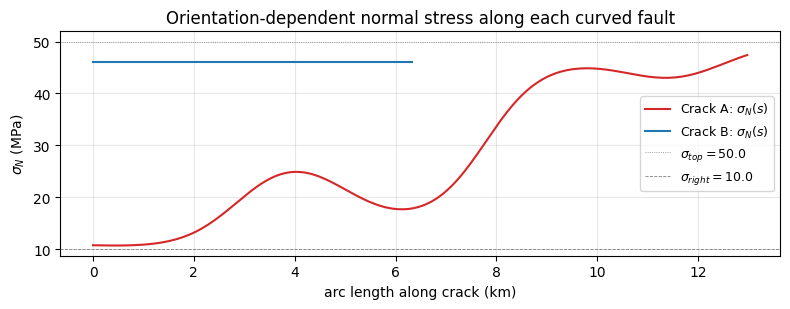

sigma_N range A : [10.73, 47.40] MPa
sigma_N range B : [46.00, 46.00] MPa


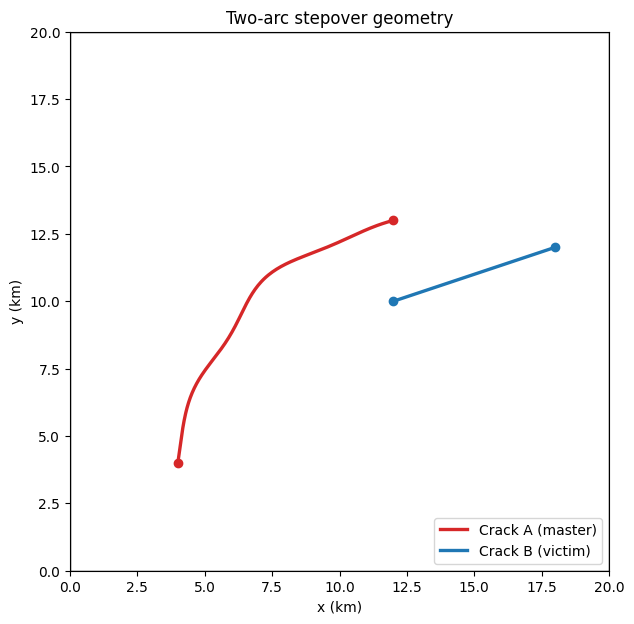

In [5]:
def parabolic_arc_xy(p_start, p_end, sagitta):
    """Parabolic arc parameterisation.  Returns X(t), dXdt(t) functions
    consistent with the existing RobustCrackGenerator convention: scalar
    t -> (2,) array; 1-D t -> (2, n) array."""
    p1 = np.asarray(p_start, dtype=float).ravel()
    p2 = np.asarray(p_end,   dtype=float).ravel()
    chord = p2 - p1
    chord_len = float(np.linalg.norm(chord))
    if chord_len <= 0.0:
        raise ValueError("arc endpoints must be distinct")
    perp = np.array([-chord[1], chord[0]]) / chord_len  # 90° CCW from chord
    sag = float(sagitta)

    def X(t):
        tt = np.asarray(t, dtype=float)
        if tt.ndim == 0:
            tv = tt.reshape(1)
        else:
            tv = tt.ravel()
        base = np.outer(1.0 - tv, p1) + np.outer(tv, p2)
        bow = (4.0 * sag * tv * (1.0 - tv))[:, None] * perp[None, :]
        out = (base + bow).T   # shape (2, n)
        if tt.ndim == 0:
            return out.reshape(2,)
        return out

    def dXdt(t):
        tt = np.asarray(t, dtype=float)
        if tt.ndim == 0:
            tv = tt.reshape(1)
        else:
            tv = tt.ravel()
        slope = (4.0 * sag * (1.0 - 2.0 * tv))[:, None] * perp[None, :]
        base = np.tile(chord, (tv.size, 1))
        out = (base + slope).T  # shape (2, n)
        if tt.ndim == 0:
            return out.reshape(2,)
        return out

    return X, dXdt


def sinusoidal_arc_xy(p_start, p_end, amplitude, n_periods=2):
    """Sinusoidal crack: chord modulated perpendicular by an envelope-tapered
    sinusoid.  Envelope sin(pi t) pins the curve to p_start at t=0 and p_end
    at t=1; inner sin(2 pi n_periods t) ripples along the arc.

    Maximum transverse displacement from the chord is ``amplitude``.
    Tangent direction rotates by at most ``atan(amplitude * 2 pi * n_periods
    / chord_length)`` from the chord direction -- this sets how strongly the
    local crack normal swings across the failure-cone band.
    """
    p1 = np.asarray(p_start, dtype=float).ravel()
    p2 = np.asarray(p_end,   dtype=float).ravel()
    chord = p2 - p1
    chord_len = float(np.linalg.norm(chord))
    if chord_len <= 0.0:
        raise ValueError('arc endpoints must be distinct')
    perp  = np.array([-chord[1], chord[0]]) / chord_len   # 90 deg CCW
    amp   = float(amplitude)
    omega = 2.0 * np.pi * float(n_periods)

    def _shape(tv):
        return np.sin(np.pi * tv) * np.sin(omega * tv)

    def _shape_deriv(tv):
        return (np.pi * np.cos(np.pi * tv) * np.sin(omega * tv)
                + np.sin(np.pi * tv) * omega * np.cos(omega * tv))

    def X(t):
        tt = np.asarray(t, dtype=float)
        tv = tt.reshape(1) if tt.ndim == 0 else tt.ravel()
        base = np.outer(1.0 - tv, p1) + np.outer(tv, p2)
        bow  = (amp * _shape(tv))[:, None] * perp[None, :]
        out  = (base + bow).T
        return out.reshape(2,) if tt.ndim == 0 else out

    def dXdt(t):
        tt = np.asarray(t, dtype=float)
        tv = tt.reshape(1) if tt.ndim == 0 else tt.ravel()
        slope = (amp * _shape_deriv(tv))[:, None] * perp[None, :]
        base  = np.tile(chord, (tv.size, 1))
        out   = (base + slope).T
        return out.reshape(2,) if tt.ndim == 0 else out

    return X, dXdt


def parabolic_plus_sine_xy(p_start, p_end, sagitta, amplitude, n_periods=2):
    """Combined parabolic bow + sinusoidal modulation, both transverse to
    the chord.  Shape: bow(t) = 4*sagitta*t*(1-t) + amp*sin(pi t)*sin(2 pi n_p t).
    Both terms vanish at t=0 and t=1 so endpoints stay anchored.

    Use this when you want a single smooth bow (parabolic part) holding the
    average orientation in the failure cone, with a smaller sinusoidal
    ripple on top for visual / geometric complexity."""
    p1 = np.asarray(p_start, dtype=float).ravel()
    p2 = np.asarray(p_end,   dtype=float).ravel()
    chord = p2 - p1
    chord_len = float(np.linalg.norm(chord))
    if chord_len <= 0.0:
        raise ValueError('arc endpoints must be distinct')
    perp  = np.array([-chord[1], chord[0]]) / chord_len
    sag   = float(sagitta)
    amp   = float(amplitude)
    omega = 2.0 * np.pi * float(n_periods)

    def _shape(tv):
        return (4.0 * sag * tv * (1.0 - tv)
                + amp * np.sin(np.pi * tv) * np.sin(omega * tv))

    def _shape_deriv(tv):
        return (4.0 * sag * (1.0 - 2.0 * tv)
                + amp * (np.pi * np.cos(np.pi * tv) * np.sin(omega * tv)
                         + np.sin(np.pi * tv) * omega * np.cos(omega * tv)))

    def X(t):
        tt = np.asarray(t, dtype=float)
        tv = tt.reshape(1) if tt.ndim == 0 else tt.ravel()
        base = np.outer(1.0 - tv, p1) + np.outer(tv, p2)
        bow  = _shape(tv)[:, None] * perp[None, :]
        out  = (base + bow).T
        return out.reshape(2,) if tt.ndim == 0 else out

    def dXdt(t):
        tt = np.asarray(t, dtype=float)
        tv = tt.reshape(1) if tt.ndim == 0 else tt.ravel()
        slope = _shape_deriv(tv)[:, None] * perp[None, :]
        base  = np.tile(chord, (tv.size, 1))
        out   = (base + slope).T
        return out.reshape(2,) if tt.ndim == 0 else out

    return X, dXdt


# --- Two-arc stepover geometry --------------------------------------------
# Endpoints chosen so the domain (20x20 km) holds both faults plus an
# inter-fault gap of ~1 km between the apices of the two arcs.
# Crack A (master): parabolic bow puts most of A deep in the Mohr-Coulomb
# failure cone (alpha_n in (40.7, 80.2) deg), with a small sinusoidal
# ripple on top for visual / geometric complexity.  The result: a large
# fraction of A's arc-length sees |tau_geo| > mu_s * sigma_N and slips
# from t=0 by orientation alone -- this is the angle-driven nucleation.
ARC_A_START      = np.array([4.0,  4.0])
ARC_A_END        = np.array([12.0, 13.0])
ARC_A_SAGITTA    = 2.
ARC_A_AMPLITUDE  = 0.25
ARC_A_N_PERIODS  = 2

# Crack B (victim): straight angled line just outside the failure cone.
# Chord direction 9.46 deg from horizontal -> alpha_n ~ 80.5 deg, just past
# the cone boundary (80.2 deg).  Uniform along the arc (no curvature),
# margin ~0.14 MPa everywhere -- easy for A's wavefield to trigger.
ARC_B_START      = np.array([12.0, 10.0])
ARC_B_END        = np.array([18.0, 12.0])
ARC_B_SAGITTA    = 0.0          # straight line -- no perpendicular bow

X_crack_A, dXdt_crack_A = parabolic_plus_sine_xy(
    ARC_A_START, ARC_A_END,
    sagitta=ARC_A_SAGITTA,
    amplitude=ARC_A_AMPLITUDE,
    n_periods=ARC_A_N_PERIODS,
)
X_crack_B, dXdt_crack_B = parabolic_arc_xy(
    ARC_B_START, ARC_B_END, ARC_B_SAGITTA,
)


def _arc_length_numeric(X_fn, n=400):
    ts = np.linspace(0.0, 1.0, n)
    pts = np.array([np.asarray(X_fn(float(t))).reshape(2,) for t in ts])
    return float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))


ARC_A_LENGTH = _arc_length_numeric(X_crack_A)
ARC_B_LENGTH = _arc_length_numeric(X_crack_B)
print(f'Crack A: {ARC_A_START.tolist()} -> {ARC_A_END.tolist()}, '
      f'sagitta={ARC_A_SAGITTA}, amp={ARC_A_AMPLITUDE}, '
      f'n_periods={ARC_A_N_PERIODS}, arc length={ARC_A_LENGTH:.3f} km')
print(f'Crack B: {ARC_B_START.tolist()} -> {ARC_B_END.tolist()}, '
      f'sagitta={ARC_B_SAGITTA} (straight line), '
      f'arc length={ARC_B_LENGTH:.3f} km')

# Length scale for displacements (needed by SW config + unit-verification cells).
# Originally lived in the constant-friction analytical-reference cell we dropped.
DISP_SCALE = SCALE_L * SCALE_EPS

# Quick orientation-dependent prestress preview along each arc to confirm
# spatial variation -- sigma_N(t) depends on local normal, so along a curve
# it changes continuously.  Plot sigma_N(s) for both arcs.
def _normal_along_arc(X_fn, dX_fn, ts):
    Ts = np.array([np.asarray(dX_fn(float(t))).reshape(2,) for t in ts])
    Ts_n = Ts / np.linalg.norm(Ts, axis=1, keepdims=True)
    # 90° CCW rotation -> outward normal (sign is arbitrary; magnitude is what matters)
    return np.stack([-Ts_n[:, 1], Ts_n[:, 0]], axis=1)

ts_pre = np.linspace(0.0, 1.0, 200)
n_along_A = _normal_along_arc(X_crack_A, dXdt_crack_A, ts_pre)
n_along_B = _normal_along_arc(X_crack_B, dXdt_crack_B, ts_pre)
sigma_N_along_A = SIGMA_RIGHT * n_along_A[:, 0]**2 + SIGMA_TOP * n_along_A[:, 1]**2
sigma_N_along_B = SIGMA_RIGHT * n_along_B[:, 0]**2 + SIGMA_TOP * n_along_B[:, 1]**2

fig_sn, ax_sn = plt.subplots(figsize=(8, 3.2))
ax_sn.plot(ts_pre * ARC_A_LENGTH, sigma_N_along_A,
           'C3-', label=r'Crack A: $\sigma_N(s)$')
ax_sn.plot(ts_pre * ARC_B_LENGTH, sigma_N_along_B,
           'C0-', label=r'Crack B: $\sigma_N(s)$')
ax_sn.axhline(SIGMA_TOP, color='gray', ls=':', lw=0.6, label=f'$\sigma_{{top}} = {SIGMA_TOP}$')
ax_sn.axhline(SIGMA_RIGHT, color='gray', ls='--', lw=0.6, label=f'$\sigma_{{right}} = {SIGMA_RIGHT}$')
ax_sn.set_xlabel('arc length along crack (km)')
ax_sn.set_ylabel(r'$\sigma_N$ (MPa)')
ax_sn.set_title('Orientation-dependent normal stress along each curved fault')
ax_sn.legend(loc='best', fontsize=9)
ax_sn.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'sigma_N range A : [{sigma_N_along_A.min():.2f}, {sigma_N_along_A.max():.2f}] MPa')
print(f'sigma_N range B : [{sigma_N_along_B.min():.2f}, {sigma_N_along_B.max():.2f}] MPa')

# Quick visual: just the two arcs over the domain rectangle.
fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Rectangle((XMIN, YMIN), XMAX-XMIN, YMAX-YMIN,
                           edgecolor='black', facecolor='none', lw=1))
ts_plot = np.linspace(0.0, 1.0, 200)
ptsA = np.array([np.asarray(X_crack_A(float(t))).reshape(2,) for t in ts_plot])
ptsB = np.array([np.asarray(X_crack_B(float(t))).reshape(2,) for t in ts_plot])
ax.plot(ptsA[:, 0], ptsA[:, 1], 'C3-', lw=2.4, label='Crack A (master)')
ax.plot(ptsB[:, 0], ptsB[:, 1], 'C0-', lw=2.4, label='Crack B (victim)')
ax.plot(*ARC_A_START, 'C3o'); ax.plot(*ARC_A_END, 'C3o')
ax.plot(*ARC_B_START, 'C0o'); ax.plot(*ARC_B_END, 'C0o')
ax.set_aspect('equal'); ax.set_xlim(XMIN, XMAX); ax.set_ylim(YMIN, YMAX)
ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
ax.set_title('Two-arc stepover geometry'); ax.legend(loc='lower right')
plt.show()


In [6]:
from skfem import MeshTri, MeshQuad, ElementTriP1, ElementQuad1
from poroelasticity.cgporoelastostatics import ElementTriP1Bubble, ElementQuad1Bubble
from poroelasticity.crack_generator import RobustCrackGenerator

# --- Structured scikit-fem mesh ----------------------------------------
_xs = np.linspace(XMIN, XMAX, N_ELEM + 1)
_ys = np.linspace(YMIN, YMAX, N_ELEM + 1)
if MESH_TYPE == 'tri':
    mesh_s = MeshTri.init_tensor(_xs, _ys)
    el_p_s = ElementTriP1()
    el_u_s = ElementTriP1Bubble()
elif MESH_TYPE == 'quad':
    mesh_s = MeshQuad.init_tensor(_xs, _ys)
    el_p_s = ElementQuad1()
    el_u_s = ElementQuad1Bubble()
else:
    raise ValueError(f"MESH_TYPE must be 'tri' or 'quad', got {MESH_TYPE!r}")

mesh_s = mesh_s.with_boundaries({
    'left':   lambda x: np.isclose(x[0], XMIN),
    'right':  lambda x: np.isclose(x[0], XMAX),
    'top':    lambda x: np.isclose(x[1], YMAX),
    'bottom': lambda x: np.isclose(x[1], YMIN),
})

# Uniform cell size of the structured mesh.
h_struct = (XMAX - XMIN) / float(N_ELEM)

crack_A = RobustCrackGenerator(
    mesh=mesh_s, X=X_crack_A, dXdt=dXdt_crack_A, d2Xdt2=None,
    verbose=True, align_min=0.1, dist_mult=h_struct,
    w_d=3.0,
)
nfacets_A = len(crack_A.surrogate_facets)
crack_A.finalize()

crack_B = RobustCrackGenerator(
    mesh=mesh_s, X=X_crack_B, dXdt=dXdt_crack_B, d2Xdt2=None,
    verbose=True, align_min=0.1, dist_mult=h_struct,
    w_d=3.0,
)
nfacets_B = len(crack_B.surrogate_facets)
crack_B.finalize()

print(f'Surrogate facets kept: {nfacets_A} on A, {nfacets_B} on B.')

h_mesh_s = float(np.max(mesh_s.param()))
print(
    f'Two-crack mesh: {mesh_s.nelements} elements, '
    f'{mesh_s.p.shape[1]} vertices, h={h_struct:.3e}, '
    f'h_max={h_mesh_s:.3e}, mesh_type={MESH_TYPE!r}'
)
print(f'  surrogate facets on A: {nfacets_A}')
print(f'  surrogate facets on B: {nfacets_B}')

# --- Multi-crack sanity check ----------------------------------------------
# The library's *sequential* split mode (used when the cracks don't
# geometrically intersect) cannot recover if A and B share original-mesh
# facets or share *original-mesh vertices*.  Detect those overlaps now and
# fail fast with an actionable message rather than blowing up later in
# `identify_crack_facets_joint`.
_surr_A_set = set(int(f) for f in crack_A.surrogate_facets)
_surr_B_set = set(int(f) for f in crack_B.surrogate_facets)
_shared_facets = _surr_A_set & _surr_B_set
_verts_A = set(mesh_s.facets[:, crack_A.surrogate_facets].ravel().astype(int).tolist())
_verts_B = set(mesh_s.facets[:, crack_B.surrogate_facets].ravel().astype(int).tolist())
_shared_verts = _verts_A & _verts_B
if _shared_facets or _shared_verts:
    print('!! Multi-crack mesh overlap detected:')
    print(f'   shared facets   = {len(_shared_facets)} '
          f'(any > 0 breaks sequential split)')
    print(f'   shared vertices = {len(_shared_verts)} '
          f'(any > 0 also breaks sequential split)')
    print('   FIX: increase N_ELEM so h_far drops below the inter-crack gap,')
    print('        or move the arcs further apart.')
    raise RuntimeError(
        'A and B share mesh facets/vertices; sequential multi-crack split '
        'will fail.  See suggestions above.'
    )
print('  OK: A and B are in geometrically disjoint mesh elements.')

bc_s = make_bc()

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s, element_u=el_u_s,
    params=PARAMS, material=MATERIAL,
    crack=[crack_A, crack_B],
    model_params=CRACK_MODEL_PARAMS,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=INCLUDE_TAYLOR,
    include_taylor_test=INCLUDE_TAYLOR_TEST,
    include_hessian=INCLUDE_HESSIAN,
    include_sbm=INCLUDE_SBM,
    taylor_method='nodal',
    lumped_coupling='consistent',
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f'Two-crack solver: n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}')
print(f'  total contact nodes (n_lambda_q): {int(poro_s.n_lambda_q)}')


[RobustCrackGenerator] KDTree facet query: 40 candidates, 18 good (both endpoints within 1.0h, relaxed tips)
[RobustCrackGenerator] Facet hits: 21 | t-range=[0.016, 1.000]
[RobustCrackGenerator] 26 good facets (BOTH endpoints within h), 21 direct hits
[RobustCrackGenerator] Final: 26 good facets (no connectors)
[RobustCrackGenerator] QUAD mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 13 facets
[EXTEND] Final: 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Starting with 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 13 facets
[EXTEND] Final: 13 facets, t-range=[0.000000, 1.000000]
[RobustCrackGenerator] Articulation points: 11, removable: 2
[RobustCrackGenerator] Selected 13 connected facets
[RobustCrackGenerator] Selected t-range=[0.000, 1.000] | coverage v

## 4. Mesh / SBM surrogate visualisation


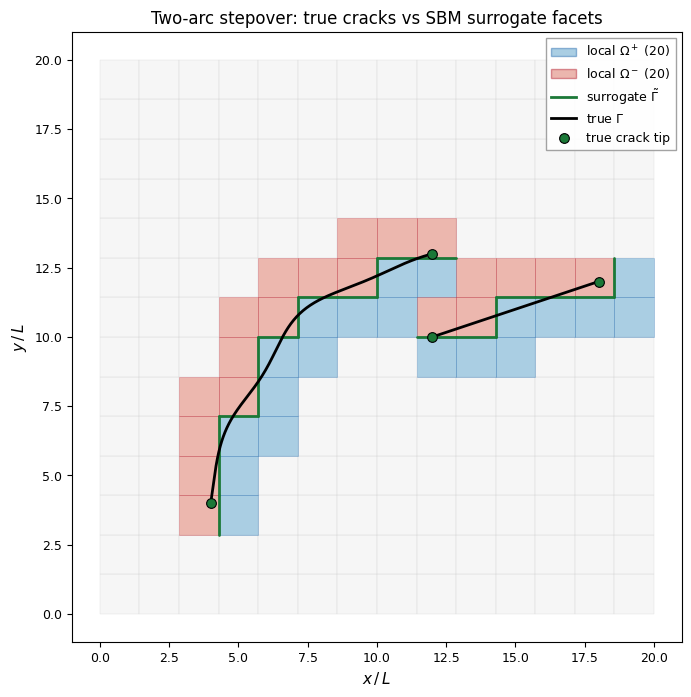

Contact node split: total=18, A=12, B=6


In [7]:
fig_sides_s, ax_sides_s = poro_s.plot_element_sides(
    show_true_crack=True,
    show_surrogate_crack=True,
    show_true_tips=True,
    show_surrogate_tips=True,
)
ax_sides_s.set_title('Two-arc stepover: true cracks vs SBM surrogate facets')
plt.show()

# Crack-aware contact-node coordinates (used downstream for prestress and
# per-crack rupture-front plots).
_lambda_coords_raw = np.asarray(
    poro_s._nodal_interface_info['lambda_coords'], dtype=float,
)
n_lambda_total = int(poro_s.n_lambda_q)
if _lambda_coords_raw.shape == (2, n_lambda_total):
    contact_xy_all = _lambda_coords_raw.T
elif _lambda_coords_raw.shape == (n_lambda_total, 2):
    contact_xy_all = _lambda_coords_raw
else:
    raise ValueError(f'unexpected lambda_coords shape {_lambda_coords_raw.shape}')


def _dist_and_param_to_curve(X_fn, pts, n_sample=400):
    ts = np.linspace(0.0, 1.0, n_sample)
    curve_pts = np.array(
        [np.asarray(X_fn(float(t))).reshape(2,) for t in ts]
    )
    diffs = pts[:, None, :] - curve_pts[None, :, :]
    d2 = np.sum(diffs ** 2, axis=2)
    idx = np.argmin(d2, axis=1)
    return np.sqrt(d2.min(axis=1)), ts[idx]


dA_node, tA_node = _dist_and_param_to_curve(X_crack_A, contact_xy_all)
dB_node, tB_node = _dist_and_param_to_curve(X_crack_B, contact_xy_all)
crack_id_per_node = np.where(dA_node <= dB_node, 0, 1)       # 0=A, 1=B
arc_t_per_node    = np.where(dA_node <= dB_node, tA_node, tB_node)
mask_A = (crack_id_per_node == 0)
mask_B = (crack_id_per_node == 1)
print(f'Contact node split: total={n_lambda_total}, '
      f'A={int(mask_A.sum())}, B={int(mask_B.sum())}')


## 5. Contact-system wiring (per-node prestress)


In [8]:

info_s = poro_s._transform_info
# In multi-crack joint mode the transform layout factors out any
# 'intersection' lambda nodes (lambdas whose plus/minus map to a
# shared mesh DOF) into a separate `n_pc` block.  The normal-lambda
# block then has size n_intf_u // 2 which may be smaller than
# n_lambda_q.  All jump-block extractors and the per-node contact
# constraints must align with this normal-lambda count.
_n_lambda_q_total = int(poro_s.n_lambda_q)
_n_intf_u_layout  = int(info_s['n_intf_u'])
_half_iu          = _n_intf_u_layout // 2
if _n_lambda_q_total != _half_iu:
    print(f'[layout] n_lambda_q={_n_lambda_q_total} != '
          f'n_intf_u/2={_half_iu}: layout split {_n_lambda_q_total - _half_iu} '
          f'lambda node(s) into the intersection (pc) block; '
          f'contact treatment will use the normal-lambda block.')
n_c_s  = _half_iu

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_avgls_s = info_s['off_avgls']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)
n_extract_s = 2 * n_c_s

# SIM-consistent contact kinematics: evaluate the constitutive variables on
# the approximate true crack, u_hat = u_tilde + Delta_j u_,j.  The stored
# transformed [[u_n]], [[u_t]] block is only the surrogate nodal jump.
# Prefer the merged library trace operators.  In multi-crack runs these
# rows must be global component-major, matching R_nt and the transformed
# multiplier layout: [all x rows, then all y rows].
C_exp_u_plus_s = getattr(poro_s, 'C_exp_u_plus', None)
C_exp_u_minus_s = getattr(poro_s, 'C_exp_u_minus', None)
if C_exp_u_plus_s is None or C_exp_u_minus_s is None:
    _per_crack_cm = getattr(poro_s, '_crack_matrices_per_crack', None)
    if _per_crack_cm and len(_per_crack_cm) > 1:
        _dim_trace_s = int(getattr(poro_s, 'dim', 2))

        def _stack_per_crack_vector_trace(_key):
            _by_comp = [[] for _ in range(_dim_trace_s)]
            for _cm in _per_crack_cm:
                _C = _cm[_key].tocsr()
                if _C.shape[0] % _dim_trace_s:
                    raise RuntimeError(
                        f'{_key} rows {_C.shape[0]} not divisible by dim={_dim_trace_s}'
                    )
                _nloc = _C.shape[0] // _dim_trace_s
                for _d in range(_dim_trace_s):
                    _by_comp[_d].append(_C[_d * _nloc:(_d + 1) * _nloc, :])
            return sp.vstack([_blk for _group in _by_comp for _blk in _group], format='csr')

        C_exp_u_plus_s = _stack_per_crack_vector_trace('C_exp_u_plus')
        C_exp_u_minus_s = _stack_per_crack_vector_trace('C_exp_u_minus')
    else:
        crack_mats_s = getattr(poro_s, '_crack_matrices', {})
        C_exp_u_plus_s  = crack_mats_s.get('C_exp_u_plus')
        C_exp_u_minus_s = crack_mats_s.get('C_exp_u_minus')
if C_exp_u_plus_s is None or C_exp_u_minus_s is None:
    raise RuntimeError('Missing shifted displacement trace operators C_exp_u_plus/minus')
C_exp_u_jump_xy_s = (C_exp_u_plus_s + C_exp_u_minus_s).tocsr()
if info_s.get('rotated_to_nt', False):
    C_exp_u_jump_nt_s = (info_s['R_nt'] @ C_exp_u_jump_xy_s).tocsr()
else:
    C_exp_u_jump_nt_s = C_exp_u_jump_xy_s

T_inv_u_static_s = poro_s._T_inv[Np_s:Np_s + Nu_s, :].tocsr()
gap_u_hat_from_z_s = (C_exp_u_jump_nt_s @ T_inv_u_static_s).tocsr()
gap_u_raw_from_z_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_base_s),
)
# SBM shift diagnostic.  Both matrices share shape only when n_intf_u
# (layout normal-lambda block) equals 2 * n_lambda_q -- i.e., no
# intersection-lambda nodes were factored out.  In multi-crack joint
# mode they can differ in row OR column count; in that case skip the
# comparison rather than crash.  gap_u_raw_from_z_s is only used here.
if gap_u_hat_from_z_s.shape == gap_u_raw_from_z_s.shape:
    _gap_shift_norm_s = sp.linalg.norm(gap_u_hat_from_z_s - gap_u_raw_from_z_s)
    _gap_hat_norm_s   = max(1.0, sp.linalg.norm(gap_u_hat_from_z_s))
    print(f"SIM shifted gap extraction ||hat-raw||/||hat|| = "
          f"{_gap_shift_norm_s / _gap_hat_norm_s:.2e}")
else:
    print(f'[multi-crack] skipping SBM shift diagnostic: '
          f'hat={gap_u_hat_from_z_s.shape} vs raw={gap_u_raw_from_z_s.shape} '
          f'(rows or cols differ -- layout has intersection-lambda or pc nodes)')

R_v_s = dyn_s.get('R_v')
if R_v_s is not None:
    D_s = (C_exp_u_jump_nt_s @ R_v_s.T).tocsr()
else:
    D_s = C_exp_u_jump_nt_s.tocsr()

A_csr_s = poro_s.A.tocsr()
B_u_s = (A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc_s:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()
reaction_state_indices_s = jmpls_cols_s[perm_s]
reaction_rows_s = np.array([row for k in range(n_c_s) for row in (k, n_c_s + k)], dtype=int)

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_phys_s = A_dyn_s.shape[0]
n_aug_phys_s = n_phys_s
n_vel_s = n_aug_phys_s - n_base_s
# Multi-crack: the C_exp_u vstack across cracks can produce more rows
# than 2*n_c_s when the layout factors out intersection-lambda nodes.
# Trust the actual matrix shape and warn loudly if it disagrees with
# the single-crack assumption so we know whether downstream wiring will
# need further per-crack adjustments.
n_extract_s_expected = 2 * n_c_s
n_extract_s = gap_u_hat_from_z_s.shape[0]
if n_extract_s != n_extract_s_expected:
    print(f'[multi-crack] gap_u_hat rows ({n_extract_s}) != 2*n_c_s '
          f'({n_extract_s_expected}); using actual row count.  '
          f'gap_u_hat.shape={gap_u_hat_from_z_s.shape}, '
          f'D_s.shape={D_s.shape}, n_base_s={n_base_s}, n_vel_s={n_vel_s}')
if gap_u_hat_from_z_s.shape[1] != n_base_s:
    print(f'[multi-crack] gap_u_hat cols ({gap_u_hat_from_z_s.shape[1]}) '
          f'!= n_base_s ({n_base_s}); column-axis hstack zeros will be '
          f'sized to match actual shape.')
assert D_s.shape[0] == n_extract_s, (
    f'D_s rows {D_s.shape[0]} != gap_u_hat rows {n_extract_s}'
)

_gap_cols = gap_u_hat_from_z_s.shape[1]
_vel_cols = D_s.shape[1]
gap_extract_dyn_s = sp.hstack(
    [gap_u_hat_from_z_s, sp.csr_matrix((n_extract_s, _vel_cols))],
    format='csr',
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, _gap_cols)), D_s],
    format='csr',
)
B_c_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)
B_dyn_s = B_c_dyn_s
B_n_dyn_s = B_c_dyn_s[:, 0::2]
B_t_dyn_s = B_c_dyn_s[:, 1::2]

vel_contact_extract_dyn_s = vel_extract_dyn_s[reaction_rows_s, :].tocsr()
M_cc_s = (vel_contact_extract_dyn_s @ B_c_dyn_s).toarray()
off_diag_s = np.max(np.abs(M_cc_s - np.diag(np.diag(M_cc_s))))
omega_s = np.diag(M_cc_s)
omega_n_s = omega_s[0::2]
omega_t_s = omega_s[1::2]
print(f"sliding D_contact @ B diag range: {omega_s.min():.3e} .. {omega_s.max():.3e}; offdiag max {off_diag_s:.3e}")
# if USE_SBM:
#     print(f"  [SBM] omega_n range: {float(omega_n_s.min()):.3e} .. {float(omega_n_s.max()):.3e}")
#     print(f"  [SBM] omega_t range: {float(omega_t_s.min()):.3e} .. {float(omega_t_s.max()):.3e}")
#     print(f"  [SBM] omega_n - omega_t max: {np.max(np.abs(omega_n_s - omega_t_s)):.3e}")
# assert np.all(omega_s > 0), "Expected positive weak-form interface weights"
# if USE_SBM:
#     assert off_diag_s <= 1e-3 * max(1.0, np.max(np.abs(omega_s))), f"off-diag {off_diag_s:.3e} exceeds SBM tol vs diag {np.max(np.abs(omega_s)):.3e}"
# else:
#     assert off_diag_s < 1e-10 * max(1.0, np.max(np.abs(omega_s)))
# if USE_SBM:
#     _diff = np.max(np.abs(omega_n_s - omega_t_s))
#     _max  = max(1.0, np.max(np.abs(omega_n_s)))
#     assert _diff <= 1e-3 * _max, f"omega_n vs omega_t mismatch {_diff:.3e} > tol"
# else:
#     assert np.allclose(omega_n_s, omega_t_s, rtol=1e-12, atol=1e-12)

off_avgp_s = info_s['off_avgp']
n_intf_p_s = info_s['n_intf_p']
assert n_intf_p_s == n_c_s, "This notebook assumes one pore-pressure trace value per contact node"
# Taylor-shifted average pressure trace at the actual crack face:
# 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
# y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
T_inv_p_static_s = poro_s._T_inv[0:Np_s, :].tocsr()
P_old_from_dyn_s = sp.hstack(
    [T_inv_p_static_s,
     sp.csr_matrix((Np_s, n_aug_phys_s - T_inv_p_static_s.shape[1]))],
    format='csr',
)
p_gamma_extract_dyn_s = (
    0.5 * (poro_s.C_exp_p_plus + poro_s.C_exp_p_minus) @ P_old_from_dyn_s
).tocsr()
# alpha=0 (pure elastodynamics) makes this correction identically zero.
# In multi-crack joint mode the shapes of B_n_dyn_s and p_gamma_extract
# can disagree (layout factors out intersection lambdas from B_n_dyn_s
# but not from C_exp_p_*), so attempting the matmul fails even though
# the result is zero.  Short-circuit to a zero matrix in that case.
if ALPHA_BIOT == 0.0:
    pressure_normal_correction_s = sp.csr_matrix(
        (B_n_dyn_s.shape[0], p_gamma_extract_dyn_s.shape[1])
    )
else:
    if B_n_dyn_s.shape[1] != p_gamma_extract_dyn_s.shape[0]:
        raise RuntimeError(
            f'pressure_normal_correction shape mismatch: '
            f'B_n_dyn_s.shape={B_n_dyn_s.shape}, '
            f'p_gamma_extract_dyn_s.shape={p_gamma_extract_dyn_s.shape}.  '
            f'In multi-crack joint mode this can happen when the layout '
            f'factors out intersection lambdas; needs per-crack handling.'
        )
    pressure_normal_correction_s = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
pressure_normal_correction_s.eliminate_zeros()
# assert pressure_normal_correction_s.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
# print("Sliding alpha-zero matrix/unit checks: PASS")

# Keep the sliding branch executable on its own during smoke checks.
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

def _contact_history(y_hist, cs_or_n_phys, n_contact, s0, w0):
    y_hist = np.asarray(y_hist, dtype=float)
    if hasattr(cs_or_n_phys, 'reaction_history'):
        r_pert = np.asarray(cs_or_n_phys.reaction_history(y_hist), dtype=float)
    else:
        n_phys = int(cs_or_n_phys)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
    r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
    return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

if USE_LYSMER:
    _C_lysmer_sliding = lysmer_descriptor_block(
        poro_s, n_phys_s, n_base_s, a_p=LYSMER_AP, a_s=LYSMER_AS,
    )
else:
    _C_lysmer_sliding = None

if USE_WINKLER:
    _K_winkler_sliding = winkler_descriptor_block(
        poro_s, n_phys_s, n_base_s,
        u_state_indices=dyn_s['u_state_indices'],
        b_p=WINKLER_BP, b_s=WINKLER_BS,
    )
else:
    _K_winkler_sliding = None

def rhs_dyn_s_eff(t, y, *extra):
    out = rhs_dyn_s(t, y, *extra) + pressure_normal_correction_s @ y
    if _C_lysmer_sliding is not None:
        out = out - _C_lysmer_sliding @ y
    if _K_winkler_sliding is not None:
        out = out - _K_winkler_sliding @ y
    return out

def rhs_jac_dyn_s_eff(t, y, *extra):
    J = rhs_jac_dyn_s(t, y, *extra) + pressure_normal_correction_s
    if _C_lysmer_sliding is not None:
        J = J - _C_lysmer_sliding
    if _K_winkler_sliding is not None:
        J = J - _K_winkler_sliding
    return J

# Per-node prestress: each contact node sees biaxial principal stresses
# applied to its own interface normal, so curved cracks get the right
# orientation-dependent sigma_N and tau automatically.
_normals_pre = np.asarray(poro_s.interface_normals[:n_c_s], dtype=float)
_n_x_pre = _normals_pre[:, 0]
_n_y_pre = _normals_pre[:, 1]
_sN_phys_per_node  = SIGMA_RIGHT * _n_x_pre**2 + SIGMA_TOP * _n_y_pre**2
_tau_phys_per_node = _n_x_pre * _n_y_pre * (SIGMA_TOP - SIGMA_RIGHT)
_s0_val_s = _sN_phys_per_node  / Sigma_scale
_w0_val_s = _tau_phys_per_node / Sigma_scale
sigma_N_sliding = float(np.median(_sN_phys_per_node))
tau_sliding_val = float(np.median(_tau_phys_per_node))

def get_s0_sliding(y):
    return _s0_val_s

def get_w0_sliding(y, k):
    return np.array([_w0_val_s[int(k)]])

flux_constraint_s = meta_s['constraints'][0]
avg_lam_s_sl_s = slice(off_avgls_s, off_avgls_s + n_lsig_s)
zero_avg_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lsig_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lsig_s: np.zeros((_n, _n)),
    'y_slice': avg_lam_s_sl_s,
    'q_slice': avg_lam_s_sl_s,
}

cs_s = build_projected_radau_contact(
    A_dyn_s,
    rhs_dyn_s_eff,
    np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    C_extract=gap_extract_dyn_s,
    D_extract=vel_extract_dyn_s,
    B=B_c_dyn_s,
    constraints=[flux_constraint_s, zero_avg_lam_s_s],
    component_slices=comp_slices_s,
    rhs_jac=rhs_jac_dyn_s_eff,
    get_s0=get_s0_sliding,
    
    get_w0=get_w0_sliding,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    reaction_state_indices=reaction_state_indices_s,
    reaction_state_to_reported_scale=0.5,
    mask_reaction_state_in_smooth_rhs=True,
)
print("sliding contact system:", cs_s.A.shape, "unknowns", cs_s.y0.size, "avg traction constrained; jump traction stores 2r")


SIM shifted gap extraction ||hat-raw||/||hat|| = 6.72e-01
Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 7.42e-01
  Exact contact weights are checked below through D_contact @ B.
sliding D_contact @ B diag range: 3.814e-01 .. 1.040e+00; offdiag max 5.295e-01
sliding contact system: (2107, 2107) unknowns 2107 avg traction constrained; jump traction stores 2r


## 10e. Optional Slip-Weakening Friction / Rupture Extension

This section augments the dynamic state with one cumulative slip variable per contact node and uses a slip-weakening friction coefficient.  Set `SW_NUCLEATION_MODE = 'patch'` to start only a finite patch weakened/slipping, `'uniform'` to pre-weaken the whole interface, or `'none'` to start from the metastable prestress without an initial weakened patch.

The diagnostics below check both the Coulomb cone and the true-crack normal gap computed from the shifted/hatted extractor, so interpenetration is assessed on `[[\hat u_n]]`, not the raw surrogate jump.

In [9]:
# # === Slip-weakening config, partial nucleation patch, and system build ======
# if CONTACT_LAW != 'soc_fb':
#     raise RuntimeError('Slip-weakening section expects CONTACT_LAW = soc_fb')

# Optional nucleation choice: 'patch' = finite central rupture seed,
# 'uniform' = whole-fault pre-weakening, 'none' = no initial weakening.
SW_NUCLEATION_MODE = 'patch'

# Slip-weakening law.  MU_STATIC_SW should match the constant-Coulomb value
# used above; MU_RES_SW < MU_STATIC_SW creates weakening.
MU_STATIC_SW = float(MU)
MU_RES_SW    = 0.32
DMU_SW       = MU_RES_SW - MU_STATIC_SW
DC_PHYS_SW   = 0.10 / 1000.0
DC_NONDIM_SW = DC_PHYS_SW / DISP_SCALE

if not (MU_RES_SW > 0.0 and MU_STATIC_SW >= MU_RES_SW):
    raise ValueError('Require 0 < MU_RES_SW <= MU_STATIC_SW')
if DC_NONDIM_SW <= 0.0:
    raise ValueError('DC_NONDIM_SW must be positive')

# Per-crack prestress utilisation -> master+victim cascade.
SW_TAU_UTIL_A = 0.965  # Crack A background: stable, but close enough for patch-driven propagation.
SW_TAU_UTIL_B = 0.985  # Crack B: stable at t=0, close enough to be triggered by A's wavefield.
                       # from A's slip; trigger should be dominated by A's *waves*.

# Per-node sigma_N and tau_geo from biaxial principal stresses applied to
# each contact node's local interface normal (assembler-supplied).
# In multi-crack joint mode the contact wiring uses n_c_s = n_intf_u // 2
# normal-lambda nodes; mask_A / mask_B / arc_t_per_node from cell 11 are
# sized to n_lambda_q (full set including intersection lambdas).  Align
# them to the normal-lambda subset by truncation.
_normals_sw = np.asarray(poro_s.interface_normals[:n_c_s], dtype=float)
_n_x = _normals_sw[:, 0]; _n_y = _normals_sw[:, 1]
sigma_N_pn  = SIGMA_RIGHT * _n_x**2 + SIGMA_TOP * _n_y**2
tau_geo_pn  = _n_x * _n_y * (SIGMA_TOP - SIGMA_RIGHT)
tau_sign_pn = np.where(tau_geo_pn >= 0.0, 1.0, -1.0)

# Align cell-11 per-node arrays to the contact-wired normal-lambda count.
mask_A         = np.asarray(mask_A)[:n_c_s]
mask_B         = np.asarray(mask_B)[:n_c_s]
arc_t_per_node = np.asarray(arc_t_per_node)[:n_c_s]

# Controlled patch-driven prestress.  Every node is below the static
# Coulomb cone at t=0; only the finite pre-weakened patch on Crack A is
# initially unstable.  This gives a clean rupture front instead of a
# geometry-selected set of angle-driven slipping nodes.
tau_util_pn = np.full(n_c_s, SW_TAU_UTIL_A, dtype=float)
tau_util_pn[mask_B] = SW_TAU_UTIL_B
tau_pre_pn = tau_sign_pn * tau_util_pn * MU_STATIC_SW * sigma_N_pn
util_pn    = np.abs(tau_pre_pn) / (MU_STATIC_SW * sigma_N_pn)

# Keep names compatible with downstream contact-system code in this cell.
sigma_N_sw_phys = sigma_N_pn        # now a per-node array (n_c_s,)
tau_sw_phys     = tau_pre_pn        # per-node prestress tangential
_s0_val_sw = sigma_N_pn / Sigma_scale
_w0_val_sw = tau_pre_pn / Sigma_scale

# Arc parameter normalized to [-1, 1] along EACH crack independently.
s_contact_sw    = 2.0 * arc_t_per_node - 1.0
sort_contact_sw = np.argsort(s_contact_sw)
abs_s_sw        = np.abs(s_contact_sw)

# Finite, tapered nucleation patch on Crack A.  Outside this patch, A is
# stable at t=0; inside it, the initial slip lowers mu enough to start
# sliding and radiate the dynamic stress pulse.
SW_PATCH_CENTER_A      = 0.40
SW_PATCH_HALF_FRACTION = 0.12
SW_INITIAL_SLIP_DC     = 1.15
_patch_xi_A = (arc_t_per_node - SW_PATCH_CENTER_A) / max(SW_PATCH_HALF_FRACTION, 1e-15)
patch_mask_A = mask_A & (np.abs(_patch_xi_A) <= 1.0)
taper_sw     = np.zeros(n_c_s, dtype=float)
taper_sw[patch_mask_A] = 0.5 * (1.0 + np.cos(np.pi * _patch_xi_A[patch_mask_A]))
slip0_sw     = SW_INITIAL_SLIP_DC * DC_NONDIM_SW * taper_sw


def mu_from_slip_sw(slip_state):
    s_eff = np.maximum(np.asarray(slip_state, dtype=float), 0.0)
    return MU_RES_SW - DMU_SW * np.exp(-s_eff / DC_NONDIM_SW)


mu0_sw           = mu_from_slip_sw(slip0_sw)
static_margin_pn = MU_STATIC_SW * sigma_N_pn - np.abs(tau_pre_pn)
local_margin0_pn = mu0_sw       * sigma_N_pn - np.abs(tau_pre_pn)
initial_sliding_nodes_sw = local_margin0_pn <= 0.0

print(
    f'Slip-weakening (two-crack): mu_static={MU_STATIC_SW:.3f}, '
    f'mu_res={MU_RES_SW:.3f}, Dc={DC_PHYS_SW * 1000:.3e} m'
)
print(f'  utilization  A = {SW_TAU_UTIL_A};  B = {SW_TAU_UTIL_B}')
print(f'  sigma_N range A = [{sigma_N_pn[mask_A].min():.3f}, '
      f'{sigma_N_pn[mask_A].max():.3f}] MPa  '
      f'(mean {sigma_N_pn[mask_A].mean():.3f})')
print(f'  sigma_N range B = [{sigma_N_pn[mask_B].min():.3f}, '
      f'{sigma_N_pn[mask_B].max():.3f}] MPa  '
      f'(mean {sigma_N_pn[mask_B].mean():.3f})')
print(f'  Initially-slipping nodes = {int(initial_sliding_nodes_sw.sum())}'
      f'/{n_c_s}  (expected: only inside A\'s patch)')

G_phys_sw = G_SHEAR
weakening_rate_A = -DMU_SW * float(np.mean(sigma_N_pn[mask_A])) / DC_PHYS_SW
weakening_rate_B = -DMU_SW * float(np.mean(sigma_N_pn[mask_B])) / DC_PHYS_SW
loading_A = G_phys_sw / ARC_A_LENGTH
loading_B = G_phys_sw / ARC_B_LENGTH
print(f'  QS-stable estimate A: G/L={loading_A:.3e}, '
      f'-Dmu*sigma/Dc={weakening_rate_A:.3e}  '
      f'(unstable: {loading_A < weakening_rate_A})')
print(f'  QS-stable estimate B: G/L={loading_B:.3e}, '
      f'-Dmu*sigma/Dc={weakening_rate_B:.3e}  '
      f'(unstable: {loading_B < weakening_rate_B})')

# Predicted dynamic stress drop and impedance ceiling per crack.
_dtau_A = (SW_TAU_UTIL_A * MU_STATIC_SW - MU_RES_SW) * float(np.mean(sigma_N_pn[mask_A]))
_dtau_B = (SW_TAU_UTIL_B * MU_STATIC_SW - MU_RES_SW) * float(np.mean(sigma_N_pn[mask_B]))
_cs_si = float(np.sqrt(G_SHEAR * 1.0e6 / DENSITY_PHYS))
print(f'  Predicted ceiling A: |v_t|_max <= {_dtau_A * 1.0e6 / (DENSITY_PHYS * _cs_si):.3f} m/s')
print(f'  Predicted ceiling B: |v_t|_max <= {_dtau_B * 1.0e6 / (DENSITY_PHYS * _cs_si):.3f} m/s')

# Initial-state diagnostics: at t = 0 only crack A's nucleation patch should
# be locally outside the friction cone.  Everything else (rest of A, all of B)
# must sit strictly inside the static cone.

# Static cone margin = mu_static * sigma_N - |tau|  (positive = stable).
margin_static_pn = MU_STATIC_SW * sigma_N_pn - np.abs(tau_pre_pn)
# Effective (slip-weakened) cone margin: nodes with initial slip > 0 see
# reduced mu => their effective margin can go negative.
margin_eff_pn = mu0_sw * sigma_N_pn - np.abs(tau_pre_pn)

A_patch_idx        = np.where(patch_mask_A)[0]
A_offpatch_idx     = np.where(mask_A & ~patch_mask_A)[0]
B_idx              = np.where(mask_B)[0]

initially_slipping = margin_eff_pn <= 0.0
n_slip_total       = int(initially_slipping.sum())
n_slip_A_patch     = int(initially_slipping[A_patch_idx].sum()) if A_patch_idx.size else 0
n_slip_A_offpatch  = int(initially_slipping[A_offpatch_idx].sum()) if A_offpatch_idx.size else 0
n_slip_B           = int(initially_slipping[B_idx].sum()) if B_idx.size else 0

print()
print('--- initial sliding state at t = 0 -----------------------------------')
print(f'  Crack A   : {int(mask_A.sum())} contact nodes')
print(f'    in nucleation patch        : {A_patch_idx.size:3d} nodes,'
      f' initially slipping = {n_slip_A_patch:3d}  '
      f'(should equal patch count -- this is the rupture seed)')
print(f'    outside nucleation patch   : {A_offpatch_idx.size:3d} nodes,'
      f' initially slipping = {n_slip_A_offpatch:3d}  '
      f'(MUST be 0 -- otherwise A''s whole fault rips at t=0)')
print(f'    static margin (off-patch)  : '
      f'min = {(margin_static_pn[A_offpatch_idx].min() if A_offpatch_idx.size else float("nan")):.4f} MPa, '
      f'max = {(margin_static_pn[A_offpatch_idx].max() if A_offpatch_idx.size else float("nan")):.4f} MPa')
print(f'  Crack B   : {int(mask_B.sum())} contact nodes')
print(f'    initially slipping         : {n_slip_B:3d}  '
      f'(MUST be 0 -- B should only react to A''s waves)')
print(f'    static margin              : '
      f'min = {margin_static_pn[B_idx].min():.4f} MPa, '
      f'max = {margin_static_pn[B_idx].max():.4f} MPa')
print(f'  Total initially slipping     : {n_slip_total} (= patch size on A)')
print('----------------------------------------------------------------------')

# Patch-driven cascade guards.
#   * Some of A must be unstable in the finite patch.
#   * A outside the patch and all of B must remain sub-critical at t=0.
#   * B should only react after A radiates stress.
_n_A_total       = int(mask_A.sum())
_n_slip_A_total  = int(initially_slipping[np.where(mask_A)[0]].sum())
assert _n_slip_A_total > 0, (
    'No nodes on A are naturally above the cone -- nothing will nucleate.  '
    'Raise A''s curvature (sagitta) or push its chord angle deeper into '
    "the failure band (currently alpha_n must be inside (40.7, 80.2) deg).")
assert _n_slip_A_total < _n_A_total, (
    f'All {_n_A_total} nodes of A are above the cone -- A would slip '
    'uniformly with no propagating front.  Soften A''s curvature.'
)
assert n_slip_A_offpatch == 0, (
    f'{n_slip_A_offpatch} off-patch A nodes are initially sliding -- '
    'lower SW_TAU_UTIL_A or shrink the patch.'
)
assert n_slip_B == 0, (
    f'{n_slip_B} nodes on B are already past the static cone -- B is NOT '
    'genuinely stable.  Rotate B''s chord further toward horizontal (alpha_n '
    '~85 deg) or reduce its sagitta.'
)
print(f'  patch-driven nucleation: {_n_slip_A_total}/{_n_A_total} '
      f'A-nodes initially sliding; {n_slip_B}/{int(mask_B.sum())} B-nodes')

D_len_sw           = 0.5 * (ARC_A_LENGTH + ARC_B_LENGTH)  # legacy scalar fallback
expd_slip_phys_sw  = -DMU_SW * float(np.mean(sigma_N_pn)) * D_len_sw / G_phys_sw

# === State augmentation: append cumulative slip s_k per contact node =======
n_phys_old_sw = n_phys_s
slip_slice_sw = slice(n_phys_old_sw, n_phys_old_sw + n_c_s)
n_aug_sw = slip_slice_sw.stop

A_aug_sw = sp.block_diag([A_dyn_s, sp.eye(n_c_s, format='csr')], format='csr')

# Tangential true-crack slip-rate extraction, row order [n-block, t-block].
vel_t_extract_sw = vel_extract_dyn_s[n_c_s:2 * n_c_s, :].tocsr()


def rhs_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    out = np.zeros(n_aug_sw)
    out[:n_phys_old_sw] = rhs_dyn_s_eff(t, y_phys)
    out[slip_slice_sw] = np.abs(vel_t_extract_sw @ y_phys)
    return out


def rhs_jac_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    J_phys = rhs_jac_dyn_s_eff(t, y_phys)
    if not sp.issparse(J_phys):
        J_phys = sp.csr_matrix(J_phys)
    v_t = np.asarray(vel_t_extract_sw @ y_phys, dtype=float).ravel()
    J_slip = sp.diags(np.sign(v_t)) @ vel_t_extract_sw
    return sp.bmat(
        [
            [J_phys, sp.csr_matrix((n_phys_old_sw, n_c_s))],
            [J_slip, sp.csr_matrix((n_c_s, n_c_s))],
        ],
        format='csr',
    )

# Pad contact wiring with zero columns/rows for the slip-history block.
gap_extract_sw = sp.hstack(
    [gap_extract_dyn_s, sp.csr_matrix((gap_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
vel_extract_sw = sp.hstack(
    [vel_extract_dyn_s, sp.csr_matrix((vel_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
B_c_sw = sp.vstack(
    [B_c_dyn_s, sp.csr_matrix((n_c_s, B_c_dyn_s.shape[1]))],
    format='csr',
)
reaction_state_indices_sw = np.asarray(reaction_state_indices_s, dtype=int)

# Per-contact slip-weakening mu and analytical dmu/dy.
def _make_mu_sw(k):
    idx = slip_slice_sw.start + int(k)
    def _mu(y, t=None, Fk_val=None):
        return float(mu_from_slip_sw(y[idx]))
    return _mu


def _make_dmu_dy_sw(k):
    idx = slip_slice_sw.start + int(k)
    def _dmu(y, t=None, Fk_val=None):
        out = np.zeros(n_aug_sw)
        s_k = float(y[idx])
        if s_k > 0.0:
            out[idx] = (DMU_SW / DC_NONDIM_SW) * np.exp(-s_k / DC_NONDIM_SW)
        return out
    return _dmu


contacts_sw = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': _make_mu_sw(k),
        'dmu_dy': _make_dmu_dy_sw(k),
        'e': 0.0,
    }
    for k in range(n_c_s)
]


def get_s0_sw(y):
    return _s0_val_sw


def get_w0_sw(y, k):
    return np.array([_w0_val_sw[int(k)]])


component_slices_sw = list(comp_slices_s) + [slip_slice_sw]
cs_sw = build_projected_radau_contact(
    A_aug_sw,
    rhs_sw,
    np.zeros(n_aug_sw),
    contacts=contacts_sw,
    C_extract=gap_extract_sw,
    D_extract=vel_extract_sw,
    B=B_c_sw,
    constraints=[flux_constraint_s, zero_avg_lam_s_s],
    component_slices=component_slices_sw,
    rhs_jac=rhs_jac_sw,
    get_s0=get_s0_sw,
    get_w0=get_w0_sw,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law= CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    reaction_state_indices=reaction_state_indices_sw,
    reaction_state_to_reported_scale=0.5,
    mask_reaction_state_in_smooth_rhs=True,
)
print(
    f'slip-weakening contact system: A={cs_sw.A.shape}, |y0|={cs_sw.y0.size}, '
    f'slip block={slip_slice_sw}, reaction state is [[t]]=2r',
)


Slip-weakening (two-crack): mu_static=0.600, mu_res=0.320, Dc=1.000e-01 m
  utilization  A = 0.965;  B = 0.985
  sigma_N range A = [10.737, 45.462] MPa  (mean 28.240)
  sigma_N range B = [46.000, 46.000] MPa  (mean 46.000)
  Initially-slipping nodes = 2/18  (expected: only inside A's patch)
  QS-stable estimate A: G/L=7.707e+02, -Dmu*sigma/Dc=7.907e+04  (unstable: True)
  QS-stable estimate B: G/L=1.581e+03, -Dmu*sigma/Dc=1.288e+05  (unstable: True)
  Predicted ceiling A: |v_t|_max <= 1.408 m/s
  Predicted ceiling B: |v_t|_max <= 2.399 m/s

--- initial sliding state at t = 0 -----------------------------------
  Crack A   : 12 contact nodes
    in nucleation patch        :   3 nodes, initially slipping =   2  (should equal patch count -- this is the rupture seed)
    outside nucleation patch   :   9 nodes, initially slipping =   0  (MUST be 0 -- otherwise As whole fault rips at t=0)
    static margin (off-patch)  : min = 0.2255 MPa, max = 0.9547 MPa
  Crack B   : 6 contact nodes
    in

In [10]:
def _attempt_accept_array(attempts):
    if attempts is None:
        return None
    if isinstance(attempts, dict):
        return np.asarray(attempts.get('accepted', []), dtype=bool)
    return np.asarray(attempts, dtype=bool)


# === Solve slip-weakening sliding test ===================================
n_aug_total_sw = cs_sw.y0.size
nl_atol_sw = np.full(n_aug_total_sw, 1e-8)
nl_rtol_sw = np.full(n_aug_total_sw, 1e-6)

# Slip block: absolute tolerance in nondimensional displacement units.
nl_atol_sw[slip_slice_sw] = min(1e-8, 1e-6 * DC_NONDIM_SW)
nl_rtol_sw[slip_slice_sw] = 0.0

# Reaction storage block is [[t]]=2r, so its tolerance is twice the r tolerance.
reaction_state_idx_sw = getattr(cs_sw, 'reaction_state_indices', None)
if reaction_state_idx_sw is not None:
    nl_atol_sw[reaction_state_idx_sw] = 1e-10
    nl_rtol_sw[reaction_state_idx_sw] = 0.0

solver_opts_sw = dict(cs_sw.solver_opts)
solver_opts_sw.update(
    tol=1e-8,
    max_iter=80,
    globalization='none',
    rhs_jac=cs_sw.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
    petsc_reuse_steps=50,
)
integrator_opts_sw = dict(cs_sw.integrator_opts)
integrator_opts_sw.update({'stages': 2, 'use_coupled_newton': True})


def coulomb_cone_warm_start_nodewise(s0_arr, w0_arr, mu_arr):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu_arr = np.asarray(mu_arr, dtype=float).ravel()
    out = np.zeros(2 * s0_arr.size)
    for k, (s0_k, w0_k, mu_k) in enumerate(zip(s0_arr, w0_arr, mu_arr)):
        out[2 * k:2 * k + 2] = coulomb_cone_warm_start(
            np.array([s0_k]), np.array([w0_k]), float(mu_k),
        )
    return out


# Initial condition: only the central patch starts weakened, and the reaction
# state is warm-started onto the local cone for mu(s0).
y0_sw_init = cs_sw.y0.copy()
y0_sw_init[slip_slice_sw] = slip0_sw
warm_r_sw = coulomb_cone_warm_start_nodewise(_s0_val_sw, _w0_val_sw, mu0_sw)
y0_sw_init[reaction_state_idx_sw] = warm_r_sw / cs_sw.reaction_state_to_reported_scale

skip_error_indices_sw = [0]
skip_error_indices_sw.extend(i for i in range(8, 13) if i < len(cs_sw.component_slices))

TMAX_SW_PHYS = TMAX_PHYS
TMAX_SW = TMAX_SW_PHYS / TIME_UNIT_TO_PHYS

# Output-time policy.  The fastest/safest default is to let the adaptive
# solver return its accepted steps (t_eval=None).  Use 'movie' only when you
# specifically need the old dense, fixed output grid for frame exports.
SW_T_EVAL_MODE = 'accepted' if FAST_OUTPUT_MODE else 'movie'
SW_USE_T_EVAL = (SW_T_EVAL_MODE != 'accepted')
SW_T_EVAL_FAST_END_PHYS = min(1.50, TMAX_SW_PHYS)
SW_T_EVAL_MID_END_PHYS = min(7.50, TMAX_SW_PHYS)
SW_T_EVAL_FAST_COUNT = 20
SW_T_EVAL_MID_COUNT = 20
SW_T_EVAL_TAIL_COUNT = 20

if SW_USE_T_EVAL:
    _segments_t_eval_sw = [
        np.linspace(0.0, SW_T_EVAL_FAST_END_PHYS,
                    max(2, int(SW_T_EVAL_FAST_COUNT))),
    ]
    if SW_T_EVAL_MID_END_PHYS > SW_T_EVAL_FAST_END_PHYS:
        _segments_t_eval_sw.append(
            np.linspace(SW_T_EVAL_FAST_END_PHYS, SW_T_EVAL_MID_END_PHYS,
                        max(2, int(SW_T_EVAL_MID_COUNT)))
        )
    if TMAX_SW_PHYS > SW_T_EVAL_MID_END_PHYS:
        _segments_t_eval_sw.append(
            np.linspace(SW_T_EVAL_MID_END_PHYS, TMAX_SW_PHYS,
                        max(2, int(SW_T_EVAL_TAIL_COUNT)))
        )
    T_EVAL_SW_PHYS = np.unique(np.concatenate(_segments_t_eval_sw))
    T_EVAL_SW_PHYS = T_EVAL_SW_PHYS[
        (T_EVAL_SW_PHYS >= 0.0) & (T_EVAL_SW_PHYS <= TMAX_SW_PHYS)
    ]
    if T_EVAL_SW_PHYS.size == 0 or T_EVAL_SW_PHYS[0] > 0.0:
        T_EVAL_SW_PHYS = np.r_[0.0, T_EVAL_SW_PHYS]
    if T_EVAL_SW_PHYS[-1] < TMAX_SW_PHYS:
        T_EVAL_SW_PHYS = np.r_[T_EVAL_SW_PHYS, TMAX_SW_PHYS]
    T_EVAL_SW = T_EVAL_SW_PHYS / TIME_UNIT_TO_PHYS
    _dt_eval_phys_sw = np.diff(T_EVAL_SW_PHYS)
    print(f't_eval: {len(T_EVAL_SW)} requested output times; '
          f'dt_phys=[{_dt_eval_phys_sw.min():.3g}, '
          f'{_dt_eval_phys_sw.max():.3g}] s')
else:
    T_EVAL_SW_PHYS = None
    T_EVAL_SW = None
    print('t_eval: using accepted adaptive steps (no forced output grid)')

# Output/storage controls.  These do not alter the accepted steps or contact
# solution; they only control how much of the accepted-step history is copied
# back into Python for diagnostics and plotting.
SW_THIN_OUTPUT = 2 if FAST_OUTPUT_MODE else 1
SW_STORE_FK = False
SW_RECORD_ATTEMPTS = not FAST_OUTPUT_MODE
print(f'output storage: thin_output={SW_THIN_OUTPUT}, '
      f'store_fk={SW_STORE_FK}, record_attempts={SW_RECORD_ATTEMPTS}')
print(
    f'Solving slip-weakening sliding: tmax={TMAX_SW:.4g} '
    f'({TMAX_SW_PHYS:.3g} s), h0={H0_ADAPTIVE}, contact_law=soc_fb',
)

import cProfile
import io
from pathlib import Path
import pstats
import time


def _run_slip_weakening_solve_sw():
    return solve_nivp.solve_ivp_ns(
        fun=cs_sw.rhs,
        t_span=(0.0, float(TMAX_SW)),
        y0=y0_sw_init,
        method='radau_iia',
        integrator_opts=integrator_opts_sw,
        projection=cs_sw.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs_sw.component_slices},
        solver_opts=solver_opts_sw,
        adaptive=True,
        h0=H0_ADAPTIVE,
        rtol=ADAPTIVE_RTOL,
        atol=ADAPTIVE_ATOL,
        skip_error_indices=skip_error_indices_sw,
        active_set_filter=False,
        return_attempts=SW_RECORD_ATTEMPTS,
        t_eval=T_EVAL_SW,
        thin_output=SW_THIN_OUTPUT,
        store_fk=SW_STORE_FK,
        adaptive_opts=dict(
            h0=H0_ADAPTIVE,
            h_min=ADAPTIVE_H_MIN,
            h_max=ADAPTIVE_H_MAX,
            h_up=2.0,
            h_down=0.5,
            method_order=2,
        ),
        nl_atol=nl_atol_sw,
        nl_rtol=nl_rtol_sw,
        component_slices=cs_sw.component_slices,
        verbose=SOLVER_VERBOSE,
        A=cs_sw.A,
        dae_var_weight='auto',
    )


def _print_sw_cprofile(profiler, *, top_n=40, sort_keys=('cumtime', 'tottime')):
    for sort_key in sort_keys:
        stream = io.StringIO()
        stats = pstats.Stats(profiler, stream=stream).strip_dirs().sort_stats(sort_key)
        stats.print_stats(int(top_n))
        print(f'cProfile top {int(top_n)} by {sort_key}:')
        print(stream.getvalue())


if PROFILE_SW_SOLVE:
    _profile_sw = cProfile.Profile()
    _solve_start_sw = time.perf_counter()
    try:
        _solve_result_sw = _profile_sw.runcall(_run_slip_weakening_solve_sw)
    finally:
        _solve_elapsed_sw = time.perf_counter() - _solve_start_sw
        if PROFILE_SW_STATS_PATH:
            _profile_path_sw = Path(PROFILE_SW_STATS_PATH)
            _profile_path_sw.parent.mkdir(parents=True, exist_ok=True)
            _profile_sw.dump_stats(str(_profile_path_sw))
            print(f'cProfile stats written to {_profile_path_sw}')
        _print_sw_cprofile(
            _profile_sw,
            top_n=PROFILE_SW_TOP_N,
            sort_keys=PROFILE_SW_SORT_KEYS,
        )
else:
    _solve_start_sw = time.perf_counter()
    _solve_result_sw = _run_slip_weakening_solve_sw()
    _solve_elapsed_sw = time.perf_counter() - _solve_start_sw
if SW_RECORD_ATTEMPTS:
    (t_sw, y_sw, h_sw, fk_sw, info_sw, attempts_sw) = _solve_result_sw
else:
    (t_sw, y_sw, h_sw, fk_sw, info_sw) = _solve_result_sw
    attempts_sw = None

t_sw = np.asarray(t_sw, dtype=float)
y_sw = np.asarray(y_sw, dtype=float)
h_sw = np.asarray(h_sw, dtype=float)
acc_sw = _attempt_accept_array(attempts_sw)
n_acc_sw = int(acc_sw.sum()) if acc_sw is not None else None
n_rej_sw = int((~acc_sw).sum()) if acc_sw is not None else None

# --- Post-process: slip, jump, friction, reactions -------------------------
slip_state_sw = y_sw[:, slip_slice_sw]
slip_increment_sw = slip_state_sw - slip0_sw[None, :]
sliding_jump_all_sw = np.asarray((gap_extract_sw @ y_sw.T).T, dtype=float)
sliding_gap_sw = sliding_jump_all_sw[:, :n_c_s]
sliding_jump_sw = sliding_jump_all_sw[:, n_c_s:]
normal_gap_phys_sw = sliding_gap_sw * DISP_SCALE
NORMAL_GAP_TOL_PHYS_SW = max(1.0e-12, 1.0e-10 * DISP_SCALE)
min_normal_gap_post_ic_sw = float(np.min(normal_gap_phys_sw[1:])) if len(t_sw) > 1 else float(np.min(normal_gap_phys_sw))
max_normal_closure_sw = max(0.0, -min_normal_gap_post_ic_sw)
no_interpenetration_sw = min_normal_gap_post_ic_sw >= -NORMAL_GAP_TOL_PHYS_SW
sliding_vjump_sw = np.asarray((vel_extract_sw @ y_sw.T).T, dtype=float)
sliding_vn_sw = sliding_vjump_sw[:, :n_c_s]
sliding_vt_sw = sliding_vjump_sw[:, n_c_s:]
mu_eff_sw = mu_from_slip_sw(slip_state_sw)

r_pert_sw, r_total_sw_nd, r_n_sw_nd, r_t_sw_nd = _contact_history(
    y_sw, cs_sw, n_c_s, _s0_val_sw, _w0_val_sw,
)
r_n_sw = r_n_sw_nd * Sigma_scale
r_t_sw = r_t_sw_nd * Sigma_scale
cone_margin_sw = mu_eff_sw * r_n_sw - np.abs(r_t_sw)
SW_RUPTURE_SLIP_THRESHOLD_DC = 0.25
rupture_slip_threshold_sw = SW_RUPTURE_SLIP_THRESHOLD_DC * DC_NONDIM_SW
ruptured_nodes_sw = slip_increment_sw >= rupture_slip_threshold_sw
final_ruptured_nodes_sw = int(np.sum(ruptured_nodes_sw[-1]))
slip_rate_phys_sw = np.abs(sliding_vt_sw) * DISP_SCALE / TIME_UNIT_TO_PHYS

slip_max_phys = float(np.max(np.abs(sliding_jump_sw)) * DISP_SCALE)
s_max_nondim = float(np.max(slip_state_sw))
s_max_phys = s_max_nondim * DISP_SCALE
print(f'Done: {len(t_sw)} stored states, t_final={t_sw[-1]:.4e} ({t_sw[-1] * TIME_UNIT_TO_PHYS:.3g} s)')
print(f'  solve wall time          = {_solve_elapsed_sw:.2f} s')
if T_EVAL_SW is not None and len(t_sw) > 1:
    _dt_out_phys_sw = np.diff(t_sw) * TIME_UNIT_TO_PHYS
    print(f'  output dt_phys           = [{_dt_out_phys_sw.min():.3g}, {_dt_out_phys_sw.max():.3g}] s')
if acc_sw is not None:
    print(f'  steps accepted={n_acc_sw}, rejected={n_rej_sw}; h range=[{h_sw.min():.2e}, {h_sw.max():.2e}]')
else:
    print(f'  attempt logging disabled; stored h range=[{h_sw.min():.2e}, {h_sw.max():.2e}]')
print(f'  max cumulative s (m)      = {s_max_phys:.3e}')
print(f'  max |[[u_t]]| (m)         = {slip_max_phys:.3e}')
print(f'  mu observed               = [{mu_eff_sw.min():.4f}, {mu_eff_sw.max():.4f}]')
print(f'  s/Dc reached              = {s_max_phys / DC_PHYS_SW:.3f}')
print(f'  slip/stress-drop estimate = {slip_max_phys / max(expd_slip_phys_sw, 1e-30):.3f}')
print(f'  ruptured nodes final      = {final_ruptured_nodes_sw}/{n_c_s} (threshold {SW_RUPTURE_SLIP_THRESHOLD_DC:.2f} Dc increment)')
print(f'  true normal gap min       = {min_normal_gap_post_ic_sw:.3e} m')
print(f'  true normal max closure   = {max_normal_closure_sw:.3e} m')
print(f'  no interpenetration       = {no_interpenetration_sw} (tol {NORMAL_GAP_TOL_PHYS_SW:.1e} m)')
if cone_margin_sw.shape[0] > 1:
    print(f'  min cone margin post-IC   = {cone_margin_sw[1:].min():.3e} MPa')
else:
    print('  min cone margin post-IC   = n/a (solver returned only the initial state)')


t_eval: using accepted adaptive steps (no forced output grid)
output storage: thin_output=2, store_fk=False, record_attempts=False
Solving slip-weakening sliding: tmax=21.6 (6 s), h0=1.008115219752334, contact_law=soc_fb
[adaptive/emb] nonlinear fail @ t=0: shrinking
[adaptive/DAE] detected 108 algebraic DOFs (of 2125 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=8.271e+01, h=5.041e-01 -> h_next=1.041e-01
[adaptive/emb] reject @ t=0, E=1.151e+01, h=1.041e-01 -> h_next=4.151e-02
[adaptive/emb] reject @ t=0, E=3.565e+00, h=4.151e-02 -> h_next=2.445e-02
[adaptive/emb] reject @ t=0, E=1.569e+00, h=2.445e-02 -> h_next=1.894e-02
[adaptive/emb] reject @ t=0, E=1.015e+00, h=1.894e-02 -> h_next=1.696e-02
[adaptive/emb] accept @ t=0 -> t+1.696e-02, E=8.369e-01, h_next=1.620e-02
[adaptive/emb] accept @ t=0.0169616 -> t+1.620e-02, E=6.019e-01, h_next=1.805e-02
[adaptive/emb] accept @ t=0.0331607 -> t+1.805e-02, E=5.760e-01, h_next=2.180e-02
[adaptive/emb] accept @ t=0.0512061 ->

/home/david/Documents/Solve_ivp_ns/solve_nivp/nonlinear_solvers.py:3327: RuntimeWarning: PETSc solver diverged: UNKNOWN(-11) after 0 iterations. For indefinite/saddle-point matrices, use ksp_type='gmres' instead of 'cg'.
  warnings.warn(


[adaptive/emb] nonlinear fail @ t=13.0006: shrinking
[adaptive/emb] accept @ t=13.0006 -> t+1.367e-02, E=2.145e-01, h_next=2.143e-02
[adaptive/emb] accept @ t=13.0143 -> t+2.143e-02, E=5.520e-01, h_next=3.231e-02
[adaptive/emb] reject @ t=13.0357, E=1.335e+00, h=3.231e-02 -> h_next=2.640e-02
[adaptive/emb] accept @ t=13.0357 -> t+2.640e-02, E=9.233e-01, h_next=2.752e-02
[adaptive/emb] accept @ t=13.0621 -> t+2.752e-02, E=8.968e-01, h_next=2.615e-02
[adaptive/emb] accept @ t=13.0896 -> t+2.615e-02, E=7.437e-01, h_next=2.668e-02
[adaptive/emb] accept @ t=13.1158 -> t+2.668e-02, E=7.215e-01, h_next=2.856e-02
[adaptive/emb] accept @ t=13.1425 -> t+2.856e-02, E=8.161e-01, h_next=2.946e-02
[adaptive/emb] accept @ t=13.171 -> t+2.946e-02, E=9.087e-01, h_next=2.855e-02
[adaptive/emb] accept @ t=13.2005 -> t+2.855e-02, E=7.932e-01, h_next=2.840e-02
[adaptive/emb] accept @ t=13.229 -> t+2.840e-02, E=8.050e-01, h_next=2.889e-02
[adaptive/emb] accept @ t=13.2574 -> t+2.889e-02, E=8.964e-01, h_next

## 7. Dashboard + snapshot grid (multi-crack)


In [11]:
# === Slip-weakening: optional dimensional full-field dashboard =============
BUILD_SW_FIELDS = True       # needed by the figure/export cells below
RUN_SW_DASHBOARD = not FAST_OUTPUT_MODE

if BUILD_SW_FIELDS:
    from poroelasticity.cg_dashboard import build_velocity_field

    _taylor_order_sw = 2 if poro_s.include_hessian else 1
    z_sw = y_sw[:, :n_base_s]

    fields_sw = poro_s.sol_to_fields_dict_with_dimensions(
        np.asarray(t_sw),
        z_sw.T,
        use_taylor_correction=True,
        taylor_order=_taylor_order_sw,
        constrained_l2=False,
    )
    fields_sw['y_raw'] = z_sw.T
    fields_sw['t_raw'] = np.asarray(t_sw)

    fields_sw['v'] = build_velocity_field(
        poro_s, y_sw, velocity_slice_s,
        scale_factor=DISP_SCALE / TIME_UNIT_TO_PHYS,
    )

    print(f'Fields extracted ({len(fields_sw)} keys, taylor_order={_taylor_order_sw})')

    dashboard_sw = CGPoroelasticDashboard(poro_s, fields_sw, levels=40)
    if RUN_SW_DASHBOARD:
        dashboard_sw.show()


Fields extracted (11 keys, taylor_order=1)


In [12]:
RUN_SW_SNAPSHOT_GRID = not FAST_OUTPUT_MODE

if RUN_SW_SNAPSHOT_GRID:
    fig_grid = dashboard_sw.snapshot_grid(
        times='auto',
        field='vmag',
        cols=4,
        shared_colorbar=True,
    )
    fig_grid.suptitle('Rupture propagation: ||v|| (m/s)')
    plt.show()


## 8. Per-crack rupture-front diagrams


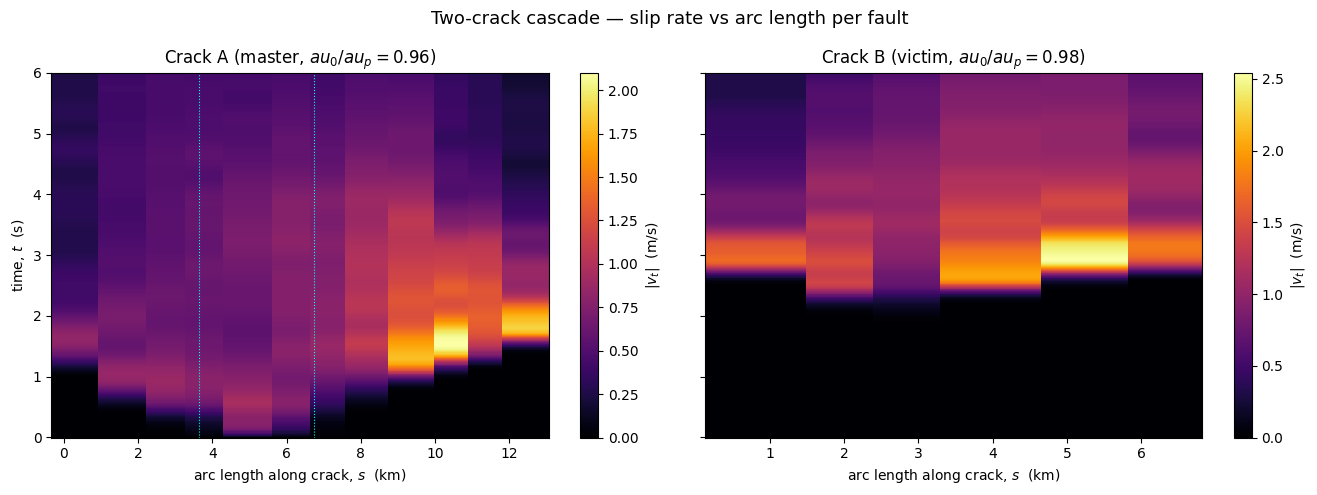

Peak |v_t| on Crack A : 2.101e+00 m/s
Peak |v_t| on Crack B : 2.544e+00 m/s
Cascade timing: peak slip on A at t = 1.546 s, peak slip on B at t = 2.939 s (delay = 1.393 s).


In [13]:
# Per-crack arc–time rupture front diagrams.  Slip rate is in m/s after the
# x1000 factor (DISP_SCALE is in km, so DISP_SCALE/T_scale -> km/s; multiply
# by 1000 for m/s).

v_t_all = np.abs(vel_t_extract_sw @ y_sw[:, :n_phys_s].T)
v_t_all = np.asarray(v_t_all, dtype=float) * (1000.0 * DISP_SCALE / TIME_UNIT_TO_PHYS)

t_phys = np.asarray(t_sw, dtype=float) * TIME_UNIT_TO_PHYS

def _per_crack_panel(ax, mask, t_param, arc_length, title, patch_extent=None):
    if not mask.any():
        ax.text(0.5, 0.5, 'no contact nodes', ha='center', va='center',
                transform=ax.transAxes)
        return None
    s_arc = t_param[mask] * arc_length
    order = np.argsort(s_arc)
    v_t   = v_t_all[mask][order, :]
    s_arc = s_arc[order]
    pcm = ax.pcolormesh(s_arc, t_phys, v_t.T, shading='auto',
                        cmap='inferno', vmin=0.0)
    if patch_extent is not None:
        for x_marker in patch_extent:
            ax.axvline(x_marker, color='cyan', ls=':', lw=0.8)
    ax.set_xlabel(r'arc length along crack, $s$  (km)')
    ax.set_title(title)
    return pcm


fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0), sharey=True)

# Patch extent on Crack A in arc-length units.
_patch_extent_A = (
    (SW_PATCH_CENTER_A - SW_PATCH_HALF_FRACTION) * ARC_A_LENGTH,
    (SW_PATCH_CENTER_A + SW_PATCH_HALF_FRACTION) * ARC_A_LENGTH,
)

pcmA = _per_crack_panel(
    axA, mask_A, arc_t_per_node, ARC_A_LENGTH,
    title=f'Crack A (master, $\tau_0/\tau_p = {SW_TAU_UTIL_A:.2f}$)',
    patch_extent=_patch_extent_A,
)
pcmB = _per_crack_panel(
    axB, mask_B, arc_t_per_node, ARC_B_LENGTH,
    title=f'Crack B (victim, $\tau_0/\tau_p = {SW_TAU_UTIL_B:.2f}$)',
)
axA.set_ylabel(r'time, $t$  (s)')
for pcm, ax in ((pcmA, axA), (pcmB, axB)):
    if pcm is not None:
        fig.colorbar(pcm, ax=ax, label=r'$|v_t|$  (m/s)')

fig.suptitle('Two-crack cascade — slip rate vs arc length per fault',
             fontsize=13)
plt.tight_layout()
plt.show()

peak_A = float(v_t_all[mask_A].max()) if mask_A.any() else 0.0
peak_B = float(v_t_all[mask_B].max()) if mask_B.any() else 0.0
print(f'Peak |v_t| on Crack A : {peak_A:.3e} m/s')
print(f'Peak |v_t| on Crack B : {peak_B:.3e} m/s')

# Approximate B-trigger delay: time at which B''s peak slip rate is reached.
if mask_B.any():
    v_t_B_max_t = v_t_all[mask_B].max(axis=0)
    t_B_peak = float(t_phys[int(np.argmax(v_t_B_max_t))])
    t_A_peak = float(t_phys[int(np.argmax(v_t_all[mask_A].max(axis=0)))]) if mask_A.any() else 0.0
    print(f'Cascade timing: peak slip on A at t = {t_A_peak:.3f} s, '
          f'peak slip on B at t = {t_B_peak:.3f} s '
          f'(delay = {t_B_peak - t_A_peak:.3f} s).')


## 9. Unit verification


In [14]:
# import numpy as np

# # Unit verification: is SCALE_L = 1 a km or a m?
# # Discriminator: T_scale = SCALE_L * sqrt(rho / Mmod) is 1000x different
# # between the two interpretations.  Comparing the library's T_scale against
# # the two analytic predictions tells us which one the library is using.

# mmod_pa  = (LAM + 2.0 * MU_LAME) * 1.0e6                # MPa -> Pa
# rho_si   = float(DENSITY_PHYS)                          # kg/m^3 in SI
# cs_si    = float(np.sqrt(G_SHEAR * 1.0e6 / rho_si))     # m/s

# t_pred_km = 1000.0 * np.sqrt(rho_si / mmod_pa)          # L = 1 km expressed in m
# t_pred_m  =          np.sqrt(rho_si / mmod_pa)          # L = 1 m

# relerr_km = abs(T_scale - t_pred_km) / t_pred_km
# relerr_m  = abs(T_scale - t_pred_m)  / t_pred_m
# unit_pos  = 'km' if relerr_km < relerr_m else 'm'

# print(f'T_scale (library output)         = {T_scale:.4e} s')
# print(f'T_scale predicted if L = 1 km    = {t_pred_km:.4e} s  (rel err {relerr_km:.2e})')
# print(f'T_scale predicted if L = 1 m     = {t_pred_m:.4e} s  (rel err {relerr_m:.2e})')
# print(f'  -> positions are in {unit_pos!r}')
# print()
# print(f'c_s                              = {cs_si:.1f} m/s = {cs_si/1000:.4f} km/s')
# print(f'Crack length                     = {CRACK_LENGTH}  (in position units)')
# print(f'Crack-crossing time:')
# print(f'  if positions [km]: {CRACK_LENGTH * 1000.0 / cs_si:.3f} s')
# print(f'  if positions [m] : {CRACK_LENGTH / cs_si:.3e} s')
# print()
# print(f'DISP_SCALE                       = {DISP_SCALE:.4e}  ({unit_pos})')
# print(f'TIME_UNIT_TO_PHYS                = {TIME_UNIT_TO_PHYS:.4e} s')
# sf_lib = DISP_SCALE / TIME_UNIT_TO_PHYS
# print(f'dashboard scale_factor used      = DISP_SCALE / TIME_UNIT_TO_PHYS = {sf_lib:.4e}')

# # Slip-rate sanity check from this run.
# peak_after_x1000 = float(v_t_arc.max())          # already multiplied by 1000 in cell 31
# peak_raw_nondim  = peak_after_x1000 / (1000.0 * sf_lib)
# peak_no_x1000    = peak_raw_nondim * sf_lib

# if unit_pos == 'km':
#     print()
#     print('CONCLUSION: dashboard label "m/s" is actually km/s.  Multiply by 1000.')
#     print(f'  rupture-front peak (this cell, x1000 applied)   = {peak_after_x1000:.4e} m/s')
#     print(f'  same peak as the dashboard would print ("m/s")  = {peak_no_x1000:.4e}')
#     print(f'  impedance ceiling for current Option-A drop     ~ 1.1 m/s')
# else:
#     print()
#     print('CONCLUSION: dashboard label "m/s" is correct as displayed.')
#     print(f'  the x1000 in the rupture-front cell should be removed.')
#     print(f'  rupture-front peak as currently shown (x1000)   = {peak_after_x1000:.4e}')
#     print(f'  rupture-front peak without x1000                = {peak_no_x1000:.4e} m/s')


In [15]:
# # === Presentation export: shifted velocity field + true-crack rupture front ===
# # Run this after the slip-weakening solve and rupture-front cells.
# from pathlib import Path
# import matplotlib.patheffects as pe
# from matplotlib import colors as mcolors
# from matplotlib.lines import Line2D

# EXPORT_FIELD_FRAMES = not FAST_OUTPUT_MODE  # Full bulk-velocity movie frames.
# EXPORT_CRACK_FRAMES = False   # Optional crack-only slip-rate/front frames.
# EXPORT_MAKE_GIF = False       # Keep False for lossless PNGs; turn on if imageio is installed.
# EXPORT_CRACK_MAKE_GIF = False
# EXPORT_N_FRAMES = 72
# EXPORT_DPI = 180
# EXPORT_DIR = Path('images/two_crack_stepover_velocity_frames')
# EXPORT_CRACK_DIR = Path('images/two_crack_stepover_crack_sliding_frames')
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# EXPORT_CRACK_DIR.mkdir(parents=True, exist_ok=True)

# EXPORT_BULK_CMAP = 'magma'
# EXPORT_SLIP_CMAP = 'inferno'
# EXPORT_BULK_PERCENTILE = 99.4
# EXPORT_SLIP_PERCENTILE = 99.5
# EXPORT_ACTIVE_FRACTION = 0.06
# EXPORT_STICKING_FRACTION = 1.0e-4

# # build_velocity_field used km/s in this notebook because positions are in km.
# # Convert to m/s for the presentation labels and colorbar.
# _v_field_mps = np.asarray(fields_sw['v'], dtype=float) * 1000.0
# _t_phys_sw = np.asarray(t_sw, dtype=float) * TIME_UNIT_TO_PHYS

# # The important SBM visualization switch: draw the velocity field on the
# # shifted geometry, i.e. crack-side vertices projected onto the true crack.
# dashboard_sw.show_surrogate_geom = False
# dashboard_sw.show_crack = False       # draw clean analytic true-crack overlays below
# dashboard_sw.show_mesh = False
# dashboard_sw._update_plot_geometry()

# try:
#     _v_t_mps = np.asarray(v_t_all, dtype=float)
# except NameError:
#     _v_t_mps = np.abs(vel_t_extract_sw @ y_sw[:, :n_phys_s].T)
#     _v_t_mps = np.asarray(_v_t_mps, dtype=float) * (1000.0 * DISP_SCALE / TIME_UNIT_TO_PHYS)

# def _curve_points_for_export(X_fn, n=600):
#     ts = np.linspace(0.0, 1.0, n)
#     return np.array([np.asarray(X_fn(float(t))).reshape(2,) for t in ts])

# _curve_A_export = _curve_points_for_export(X_crack_A)
# _curve_B_export = _curve_points_for_export(X_crack_B)

# _contact_xy_true = np.empty((n_c_s, 2), dtype=float)
# for _k in range(n_c_s):
#     if mask_A[_k]:
#         _contact_xy_true[_k] = np.asarray(X_crack_A(float(arc_t_per_node[_k]))).reshape(2,)
#     else:
#         _contact_xy_true[_k] = np.asarray(X_crack_B(float(arc_t_per_node[_k]))).reshape(2,)

# _activity_t = np.nanmax(_v_t_mps, axis=0)
# _activity_peak = float(np.nanmax(_activity_t)) if _activity_t.size else 0.0
# if _activity_peak > 0.0:
#     _active_ids = np.flatnonzero(_activity_t >= 0.015 * _activity_peak)
# else:
#     _active_ids = np.arange(len(_t_phys_sw))
# if _active_ids.size == 0:
#     _active_ids = np.arange(len(_t_phys_sw))
# _pad = max(3, int(0.08 * max(1, _active_ids.size)))
# _i0 = max(0, int(_active_ids[0]) - _pad)
# _i1 = min(len(_t_phys_sw) - 1, int(_active_ids[-1]) + _pad)
# _n_frames = min(EXPORT_N_FRAMES, _i1 - _i0 + 1)
# _frame_ids = np.unique(np.rint(np.linspace(_i0, _i1, _n_frames)).astype(int))

# def _bulk_mag_at(_tid):
#     return dashboard_sw.S_u.build_magnitude(_v_field_mps[:, _tid])

# COMPUTE_BULK_EXPORT_SCALE = True
# if COMPUTE_BULK_EXPORT_SCALE:
#     _sample_stride = max(1, len(_frame_ids) // 24)
#     _bulk_samples = []
#     for _tid in _frame_ids[::_sample_stride]:
#         _, _vals = _bulk_mag_at(int(_tid))
#         _bulk_samples.append(np.asarray(_vals, dtype=float))
#     _bulk_stack = np.concatenate(_bulk_samples) if _bulk_samples else np.array([0.0])
#     _bulk_vmax = float(np.nanpercentile(_bulk_stack, EXPORT_BULK_PERCENTILE))
#     if not np.isfinite(_bulk_vmax) or _bulk_vmax <= 0.0:
#         _bulk_vmax = max(1.0, float(np.nanmax(_bulk_stack)))
# else:
#     _bulk_vmax = 1.0
# _slip_window = _v_t_mps[:, _frame_ids] if _frame_ids.size else _v_t_mps
# _slip_vmax = float(np.nanpercentile(_slip_window, EXPORT_SLIP_PERCENTILE))
# if not np.isfinite(_slip_vmax) or _slip_vmax <= 0.0:
#     _slip_vmax = max(1.0, float(np.nanmax(_v_t_mps)))
# _active_cut = max(0.02 * _slip_vmax, EXPORT_ACTIVE_FRACTION * _activity_peak)
# _sticking_cut = max(1.0e-12, EXPORT_STICKING_FRACTION * max(_activity_peak, _slip_vmax, 1.0))

# def _draw_true_crack_export(ax):
#     for pts in (_curve_A_export, _curve_B_export):
#         ax.plot(pts[:, 0], pts[:, 1], color='white', lw=5.0,
#                 solid_capstyle='round', zorder=12)
#         ax.plot(pts[:, 0], pts[:, 1], color='black', lw=2.0,
#                 solid_capstyle='round', zorder=13)
#     if 'SW_PATCH_CENTER_A' in globals() and 'SW_PATCH_HALF_FRACTION' in globals():
#         t0 = max(0.0, SW_PATCH_CENTER_A - SW_PATCH_HALF_FRACTION)
#         t1 = min(1.0, SW_PATCH_CENTER_A + SW_PATCH_HALF_FRACTION)
#         pts = np.array([np.asarray(X_crack_A(float(t))).reshape(2,)
#                         for t in np.linspace(t0, t1, 80)])
#         ax.plot(pts[:, 0], pts[:, 1], color='#00d5ff', lw=3.4,
#                 solid_capstyle='round', zorder=14,
#                 path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])

# _CRACK_LINE_COLORS_EXPORT = ('#6b8f71', '#a07455')

# def _draw_mesh_geometry_export(ax):
#     mesh_line = mesh_s
#     for fid in range(mesh_line.facets.shape[1]):
#         v0, v1 = mesh_line.facets[:, fid]
#         ax.plot(mesh_line.p[0, [v0, v1]], mesh_line.p[1, [v0, v1]],
#                 color='0.86', lw=0.35, zorder=1)
#     for crk, color in zip((crack_A, crack_B), _CRACK_LINE_COLORS_EXPORT):
#         fids = np.asarray(getattr(crk, 'surrogate_facets', []), dtype=int)
#         for fid in fids:
#             v0, v1 = mesh_line.facets[:, int(fid)]
#             ax.plot(mesh_line.p[0, [v0, v1]], mesh_line.p[1, [v0, v1]],
#                     color=color, lw=2.0, solid_capstyle='round', zorder=5)
#     for pts, color in zip((_curve_A_export, _curve_B_export),
#                           _CRACK_LINE_COLORS_EXPORT):
#         ax.plot(pts[:, 0], pts[:, 1], color=color, lw=1.8,
#                 ls='--', dashes=(4.0, 2.4), zorder=6)
#     ax.set_aspect('equal')
#     ax.set_xlim(XMIN, XMAX)
#     ax.set_ylim(YMIN, YMAX)
#     ax.set_xlabel('x (km)')
#     ax.set_ylabel('y (km)')
#     ax.tick_params(direction='in', top=True, right=True, length=5, width=1.0)
#     ax.legend(
#         handles=[
#             Line2D([0], [0], color=_CRACK_LINE_COLORS_EXPORT[0], lw=1.8, ls='--',
#                    label=r'$\Gamma_{c0}$'),
#             Line2D([0], [0], color=_CRACK_LINE_COLORS_EXPORT[0], lw=2.0,
#                    label=r'$\tilde{\Gamma}_{c0}$'),
#             Line2D([0], [0], color=_CRACK_LINE_COLORS_EXPORT[1], lw=1.8, ls='--',
#                    label=r'$\Gamma_{c1}$'),
#             Line2D([0], [0], color=_CRACK_LINE_COLORS_EXPORT[1], lw=2.0,
#                    label=r'$\tilde{\Gamma}_{c1}$'),
#         ],
#         loc='upper right', fontsize=9, ncol=2, handlelength=2.6,
#         columnspacing=1.1, framealpha=0.92, edgecolor='0.65', fancybox=False,
#     )

# def _arc_time_panel_export(ax, mask, arc_length, title, tid, patch_extent=None):
#     s_arc = arc_t_per_node[mask] * arc_length
#     order = np.argsort(s_arc)
#     s_arc = s_arc[order]
#     vals = _v_t_mps[mask][order, :]
#     pcm = ax.pcolormesh(s_arc, _t_phys_sw, vals.T, shading='auto',
#                         cmap=EXPORT_SLIP_CMAP, vmin=0.0, vmax=_slip_vmax)
#     ax.axhline(_t_phys_sw[tid], color='#00d5ff', lw=1.8)
#     if patch_extent is not None:
#         for x_marker in patch_extent:
#             ax.axvline(x_marker, color='#00d5ff', ls=':', lw=1.0)
#     ax.set_title(title, fontsize=10)
#     ax.set_ylabel('time (s)')
#     ax.set_xlim(0.0, arc_length)
#     ax.tick_params(labelsize=8)
#     return pcm

# _patch_extent_A_export = None
# if 'SW_PATCH_CENTER_A' in globals() and 'SW_PATCH_HALF_FRACTION' in globals():
#     _patch_extent_A_export = (
#         (SW_PATCH_CENTER_A - SW_PATCH_HALF_FRACTION) * ARC_A_LENGTH,
#         (SW_PATCH_CENTER_A + SW_PATCH_HALF_FRACTION) * ARC_A_LENGTH,
#     )

# _crack_extent_pts_export = np.vstack([_curve_A_export, _curve_B_export])
# _crack_xpad_export = max(0.8, 0.08 * np.ptp(_crack_extent_pts_export[:, 0]))
# _crack_ypad_export = max(0.8, 0.12 * np.ptp(_crack_extent_pts_export[:, 1]))
# _crack_xlim_export = (
#     float(_crack_extent_pts_export[:, 0].min() - _crack_xpad_export),
#     float(_crack_extent_pts_export[:, 0].max() + _crack_xpad_export),
# )
# _crack_ylim_export = (
#     float(_crack_extent_pts_export[:, 1].min() - _crack_ypad_export),
#     float(_crack_extent_pts_export[:, 1].max() + _crack_ypad_export),
# )
# _slip_norm_export = mcolors.PowerNorm(gamma=0.45, vmin=0.0, vmax=_slip_vmax)

# def render_crack_sliding_frame(tid, frame_label=None):
#     tid = int(tid)
#     fig = plt.figure(figsize=(12.4, 5.6), constrained_layout=True)
#     gs = fig.add_gridspec(2, 2, width_ratios=(1.55, 1.0), height_ratios=(1.0, 1.0))
#     ax_map = fig.add_subplot(gs[:, 0])
#     ax_A = fig.add_subplot(gs[0, 1])
#     ax_B = fig.add_subplot(gs[1, 1], sharey=ax_A)

#     _draw_true_crack_export(ax_map)
#     vals_now = np.asarray(_v_t_mps[:, tid], dtype=float)
#     sc = ax_map.scatter(
#         _contact_xy_true[:, 0], _contact_xy_true[:, 1],
#         c=vals_now, s=70, cmap=EXPORT_SLIP_CMAP, norm=_slip_norm_export,
#         edgecolors='black', linewidths=0.55, zorder=20,
#     )
#     ruptured = ruptured_nodes_sw[tid] if 'ruptured_nodes_sw' in globals() else np.zeros(n_c_s, dtype=bool)
#     active = vals_now >= _active_cut
#     has_slid = np.any(_v_t_mps[:, :tid + 1] >= _active_cut, axis=1) | ruptured
#     sticking = vals_now <= _sticking_cut
#     stopped = has_slid & sticking
#     if np.any(stopped):
#         ax_map.scatter(_contact_xy_true[stopped, 0], _contact_xy_true[stopped, 1],
#                        s=115, facecolors='none', edgecolors='#ffd166',
#                        linewidths=1.7, zorder=22)
#     if np.any(active):
#         ax_map.scatter(_contact_xy_true[active, 0], _contact_xy_true[active, 1],
#                        s=140, facecolors='none', edgecolors='#00d5ff',
#                        linewidths=2.0, zorder=23)

#     ax_map.set_aspect('equal')
#     ax_map.set_xlim(*_crack_xlim_export)
#     ax_map.set_ylim(*_crack_ylim_export)
#     ax_map.set_xlabel('x (km)')
#     ax_map.set_ylabel('y (km)')
#     ax_map.set_title(f'True-crack slip-rate front, t = {_t_phys_sw[tid]:.3f} s')
#     ax_map.grid(True, color='0.90', lw=0.6)
#     cbar = fig.colorbar(sc, ax=ax_map, shrink=0.82, pad=0.015)
#     cbar.set_label(r'$|v_t|$ on crack (m/s)')

#     pcm_A = _arc_time_panel_export(ax_A, mask_A, ARC_A_LENGTH, 'Crack A',
#                                    tid, patch_extent=_patch_extent_A_export)
#     _arc_time_panel_export(ax_B, mask_B, ARC_B_LENGTH, 'Crack B', tid)
#     ax_A.set_xlabel('arc length s (km)')
#     ax_B.set_xlabel('arc length s (km)')
#     fig.colorbar(pcm_A, ax=[ax_A, ax_B], shrink=0.90, pad=0.02,
#                  label=r'$|v_t|$ (m/s)')
#     if frame_label is not None:
#         fig.text(0.015, 0.015, frame_label, fontsize=8, color='0.35')
#     return fig

# def render_two_crack_velocity_frame(tid, frame_label=None):
#     tid = int(tid)
#     tri, vmag = _bulk_mag_at(tid)
#     fig = plt.figure(figsize=(13.2, 9.0), constrained_layout=True)
#     gs = fig.add_gridspec(2, 2, width_ratios=(1.0, 1.0), height_ratios=(1.0, 0.95))
#     ax_mesh = fig.add_subplot(gs[0, 0])
#     ax_field = fig.add_subplot(gs[0, 1])
#     ax_A = fig.add_subplot(gs[1, 0])
#     ax_B = fig.add_subplot(gs[1, 1], sharey=ax_A)

#     _draw_mesh_geometry_export(ax_mesh)

#     levels = np.linspace(0.0, _bulk_vmax, 72)
#     cf = ax_field.tricontourf(tri, vmag, levels=levels,
#                              cmap=EXPORT_BULK_CMAP, extend='max')
#     _draw_true_crack_export(ax_field)

#     ruptured = ruptured_nodes_sw[tid] if 'ruptured_nodes_sw' in globals() else np.zeros(n_c_s, dtype=bool)
#     active = _v_t_mps[:, tid] >= _active_cut
#     has_slid = np.any(_v_t_mps[:, :tid + 1] >= _active_cut, axis=1) | ruptured
#     sticking = _v_t_mps[:, tid] <= _sticking_cut
#     stopped = has_slid & sticking
#     if np.any(stopped):
#         ax_field.scatter(_contact_xy_true[stopped, 0], _contact_xy_true[stopped, 1],
#                          s=28, facecolors='none', edgecolors='#ffd166',
#                          linewidths=1.2, zorder=16)
#     if np.any(active):
#         ax_field.scatter(_contact_xy_true[active, 0], _contact_xy_true[active, 1],
#                          s=38, facecolors='#00d5ff', edgecolors='black',
#                          linewidths=0.7, zorder=17)

#     ax_field.set_aspect('equal')
#     ax_field.set_xlim(XMIN, XMAX)
#     ax_field.set_ylim(YMIN, YMAX)
#     ax_field.set_xlabel('x (km)')
#     ax_field.set_ylabel('y (km)')
#     cbar = fig.colorbar(cf, ax=ax_field, shrink=0.86, pad=0.015)
#     cbar.set_label(r'$\Vert v \Vert$ (m/s)')

#     pcm_A = _arc_time_panel_export(ax_A, mask_A, ARC_A_LENGTH, 'Crack A slip rate',
#                                    tid, patch_extent=_patch_extent_A_export)
#     _arc_time_panel_export(ax_B, mask_B, ARC_B_LENGTH, 'Crack B slip rate', tid)
#     ax_A.set_xlabel('arc length s (km)')
#     ax_B.set_xlabel('arc length s (km)')
#     fig.colorbar(pcm_A, ax=[ax_A, ax_B], shrink=0.90, pad=0.02,
#                  label=r'$|v_t|$ (m/s)')
#     if frame_label is not None:
#         fig.text(0.015, 0.015, frame_label, fontsize=8, color='0.35')
#     return fig

# if EXPORT_FIELD_FRAMES:
#     _frame_paths = []
#     for _j, _tid in enumerate(_frame_ids):
#         _path = EXPORT_DIR / f'frame_{_j:04d}.png'
#         _fig = render_two_crack_velocity_frame(int(_tid))
#         _fig.savefig(_path, dpi=EXPORT_DPI, facecolor='white')
#         plt.close(_fig)
#         _frame_paths.append(_path)
#     print(f'Wrote {len(_frame_paths)} frames to {EXPORT_DIR}')
#     print(f'  bulk color scale: 0 .. {_bulk_vmax:.3e} m/s')
#     print(f'  slip color scale: 0 .. {_slip_vmax:.3e} m/s')

#     if EXPORT_MAKE_GIF:
#         try:
#             import imageio.v3 as iio
#             _gif_path = EXPORT_DIR.with_suffix('.gif')
#             _images = [iio.imread(p) for p in _frame_paths]
#             iio.imwrite(_gif_path, _images, duration=85, loop=0)
#             print(f'Wrote GIF to {_gif_path}')
#         except Exception as exc:
#             print(f'GIF export skipped: {exc}')

# if EXPORT_CRACK_FRAMES:
#     _crack_frame_paths = []
#     for _j, _tid in enumerate(_frame_ids):
#         _path = EXPORT_CRACK_DIR / f'frame_{_j:04d}.png'
#         _fig = render_crack_sliding_frame(int(_tid))
#         _fig.savefig(_path, dpi=EXPORT_DPI, facecolor='white')
#         plt.close(_fig)
#         _crack_frame_paths.append(_path)
#     print(f'Wrote {len(_crack_frame_paths)} crack-sliding frames to {EXPORT_CRACK_DIR}')
#     print(f'  slip color scale: 0 .. {_slip_vmax:.3e} m/s')

#     if EXPORT_CRACK_MAKE_GIF:
#         try:
#             import imageio.v3 as iio
#             _gif_path = EXPORT_CRACK_DIR.with_suffix('.gif')
#             _images = [iio.imread(p) for p in _crack_frame_paths]
#             iio.imwrite(_gif_path, _images, duration=85, loop=0)
#             print(f'Wrote crack-sliding GIF to {_gif_path}')
#         except Exception as exc:
#             print(f'Crack-sliding GIF export skipped: {exc}')


## 10. Figure-style single snapshot

This optional export does not replace the frame/dashboard outputs above. It reuses the arrays already built by the presentation-export setup and writes a frame-matched set of four-panel, publication-style snapshots to `images/two_crack_stepover_figure_snapshots/`.

Panels (c) and (d) are generated as arc-time slip-rate maps, not as 2-D bulk fields. The spatial coordinate is the scalar arc length along each true crack. Earlier in the notebook, the contact-node coordinates are read from `poro_s._nodal_interface_info['lambda_coords']`; `_dist_and_param_to_curve` samples each analytic crack curve, finds the nearest point on crack A and crack B for every contact node, assigns the node to the closest crack, and stores the corresponding curve parameter in `arc_t_per_node`. Multiplying that parameter by `ARC_A_LENGTH` or `ARC_B_LENGTH` gives the horizontal coordinate `s` used in the lower panels.

The color data in the lower panels is the tangential true-crack slip rate. It comes from `vel_t_extract_sw @ y_sw[:, :n_phys_s].T`, converted to m/s, split by `mask_A` and `mask_B`, and sorted by arc length. The figure-style cell converts the discrete contact-node centers and time samples into cell edges before calling `pcolormesh`, so each contact node is displayed as a finite arc segment through time rather than as an interpolated continuous image.


In [16]:
# # === Figure-style single snapshot export (does not replace frame exports) ===
# from pathlib import Path

# # Run this after the presentation-export setup cell above. It saves
# # publication-style four-panel snapshots to a separate directory.
# EXPORT_FIGURE_SNAPSHOT = True
# EXPORT_FIGURE_SNAPSHOT_SHOW = True
# EXPORT_FIGURE_SNAPSHOT_TID = None  # None -> use the same _frame_ids as frame export
# EXPORT_FIGURE_SNAPSHOT_DPI = 240
# EXPORT_FIGURE_SNAPSHOT_FORMATS = ('png', 'pdf')
# EXPORT_FIGURE_SNAPSHOT_DIR = Path('images/two_crack_stepover_figure_snapshots')
# EXPORT_FIGURE_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)


# def _add_panel_label(ax, label, *, color='black'):
#     ax.text(
#         -0.11, 1.035, label,
#         transform=ax.transAxes,
#         ha='left', va='bottom',
#         fontsize=14, fontweight='bold', fontfamily='serif',
#         color=color, clip_on=False, zorder=60,
#     )


# def _label_crack_curve(ax, curve, label, t_frac, offset_points):
#     curve = np.asarray(curve, dtype=float)
#     idx = int(np.clip(round(float(t_frac) * (len(curve) - 1)),
#                       0, len(curve) - 1))
#     xy = curve[idx]
#     ax.annotate(
#         label,
#         xy=(xy[0], xy[1]), xycoords='data',
#         xytext=offset_points, textcoords='offset points',
#         ha='center', va='center', fontsize=10, fontweight='bold',
#         bbox=dict(boxstyle='round,pad=0.22', facecolor='white',
#                   edgecolor='black', linewidth=0.8, alpha=0.94),
#         arrowprops=dict(arrowstyle='-', color='black', lw=1.0,
#                         shrinkA=3, shrinkB=3),
#         zorder=70,
#     )


# def _annotate_cracks_in_geometry_panel(ax):
#     return None


# def _style_crack_geometry_legend(ax):
#     colors = globals().get('_CRACK_LINE_COLORS_EXPORT',
#                            ('#6b8f71', '#6b8f71'))
#     ax.legend(
#         handles=[
#             Line2D([0], [0], color=colors[0], lw=1.8, ls='--',
#                    label=r'$\Gamma_{c0}$'),
#             Line2D([0], [0], color=colors[0], lw=2.0,
#                    label=r'$\tilde{\Gamma}_{c0}$'),
#             Line2D([0], [0], color=colors[1], lw=1.8, ls='--',
#                    label=r'$\Gamma_{c1}$'),
#             Line2D([0], [0], color=colors[1], lw=2.0,
#                    label=r'$\tilde{\Gamma}_{c1}$'),
#         ],
#         loc='upper right', fontsize=9, ncol=2, handlelength=2.6,
#         columnspacing=1.1, framealpha=0.92, edgecolor='0.65',
#         fancybox=False,
#     )


# def _choose_figure_snapshot_tid():
#     if EXPORT_FIGURE_SNAPSHOT_TID is not None:
#         return int(EXPORT_FIGURE_SNAPSHOT_TID)
#     if '_activity_t' in globals() and np.asarray(_activity_t).size:
#         return int(np.nanargmax(_activity_t))
#     return int(_frame_ids[len(_frame_ids) // 2]) if len(_frame_ids) else 0


# def _figure_snapshot_tids():
#     if EXPORT_FIGURE_SNAPSHOT_TID is not None:
#         return np.array([int(EXPORT_FIGURE_SNAPSHOT_TID)], dtype=int)
#     if '_frame_ids' in globals() and len(_frame_ids):
#         return np.asarray(_frame_ids, dtype=int)
#     return np.array([_choose_figure_snapshot_tid()], dtype=int)


# def _cell_edges_from_centers(centers, *, lower=None, upper=None):
#     centers = np.asarray(centers, dtype=float).ravel()
#     if centers.size == 0:
#         lo = 0.0 if lower is None else float(lower)
#         hi = 1.0 if upper is None else float(upper)
#         return np.array([lo, hi], dtype=float)
#     if centers.size == 1:
#         if lower is not None and upper is not None:
#             return np.array([float(lower), float(upper)], dtype=float)
#         width = 1.0
#         return np.array([centers[0] - 0.5 * width,
#                          centers[0] + 0.5 * width])

#     mid = 0.5 * (centers[:-1] + centers[1:])
#     first = centers[0] - (mid[0] - centers[0])
#     last = centers[-1] + (centers[-1] - mid[-1])
#     edges = np.concatenate([[first], mid, [last]])
#     if lower is not None:
#         edges[0] = max(edges[0], float(lower))
#     if upper is not None:
#         edges[-1] = min(edges[-1], float(upper))
#     return edges


# def _arc_time_panel_piecewise_constant(ax, mask, arc_length, tid,
#                                       patch_extent=None):
#     if not np.any(mask):
#         ax.text(0.5, 0.5, 'no contact nodes', ha='center', va='center',
#                 transform=ax.transAxes)
#         return None
#     s_arc = arc_t_per_node[mask] * arc_length
#     order = np.argsort(s_arc)
#     s_arc = s_arc[order]
#     vals = _v_t_mps[mask][order, :]
#     s_edges = _cell_edges_from_centers(s_arc, lower=0.0, upper=arc_length)
#     t_edges = _cell_edges_from_centers(_t_phys_sw)
#     # Rasterize dense filled artists in vector exports to avoid PDF hairline seams.
#     pcm = ax.pcolormesh(
#         s_edges, t_edges, vals.T, shading='flat',
#         cmap=EXPORT_SLIP_CMAP, vmin=0.0, vmax=_slip_vmax,
#         rasterized=True, edgecolors='none', linewidth=0.0,
#         antialiased=False,
#     )
#     ax.axhline(_t_phys_sw[tid], color='#00d5ff', lw=1.8)
#     if patch_extent is not None:
#         for x_marker in patch_extent:
#             ax.axvline(x_marker, color='#00d5ff', ls=':', lw=1.0)
#     ax.set_ylabel('time (s)')
#     ax.set_xlim(0.0, arc_length)
#     ax.tick_params(labelsize=8)
#     return pcm


# def render_two_crack_velocity_figure_snapshot(tid=None):
#     """Publication-style four-panel snapshot using existing export arrays."""
#     tid = _choose_figure_snapshot_tid() if tid is None else int(tid)
#     tri, vmag = _bulk_mag_at(tid)

#     fig = plt.figure(figsize=(13.2, 9.0), constrained_layout=True)
#     gs = fig.add_gridspec(2, 2, width_ratios=(1.0, 1.0),
#                           height_ratios=(1.0, 0.95))
#     ax_mesh = fig.add_subplot(gs[0, 0])
#     ax_field = fig.add_subplot(gs[0, 1])
#     ax_A = fig.add_subplot(gs[1, 0])
#     ax_B = fig.add_subplot(gs[1, 1], sharey=ax_A)

#     _draw_mesh_geometry_export(ax_mesh)
#     _annotate_cracks_in_geometry_panel(ax_mesh)
#     _style_crack_geometry_legend(ax_mesh)
#     _add_panel_label(ax_mesh, '(a)')

#     levels = np.linspace(0.0, _bulk_vmax, 72)
#     cf = ax_field.tricontourf(
#         tri, vmag, levels=levels,
#         cmap=EXPORT_BULK_CMAP, extend='max',
#         zorder=-10,
#         antialiased=False,
#     )
#     cf.set_edgecolor('face')
#     cf.set_linewidth(0.0)
#     ax_field.set_rasterization_zorder(0)
#     _draw_true_crack_export(ax_field)

#     active = _v_t_mps[:, tid] >= _active_cut
#     sticking = _v_t_mps[:, tid] <= _sticking_cut
#     if np.any(sticking):
#         ax_field.scatter(_contact_xy_true[sticking, 0],
#                          _contact_xy_true[sticking, 1],
#                          s=28, facecolors='none', edgecolors='#ffd166',
#                          linewidths=1.2, zorder=16)
#     if np.any(active):
#         ax_field.scatter(_contact_xy_true[active, 0],
#                          _contact_xy_true[active, 1],
#                          s=38, facecolors='#00d5ff', edgecolors='black',
#                          linewidths=0.7, zorder=17)

#     ax_field.set_aspect('equal')
#     ax_field.set_xlim(XMIN, XMAX)
#     ax_field.set_ylim(YMIN, YMAX)
#     ax_field.set_xlabel('x (km)')
#     ax_field.set_ylabel('y (km)')
#     _add_panel_label(ax_field, '(b)')
#     cbar = fig.colorbar(cf, ax=ax_field, shrink=0.86, pad=0.015)
#     cbar.set_label(r'$\Vert v \Vert$ (m/s)')

#     pcm_A = _arc_time_panel_piecewise_constant(
#         ax_A, mask_A, ARC_A_LENGTH, tid,
#         patch_extent=_patch_extent_A_export)
#     pcm_B = _arc_time_panel_piecewise_constant(
#         ax_B, mask_B, ARC_B_LENGTH, tid)
#     ax_A.set_xlabel('arc length s (km)')
#     ax_B.set_xlabel('arc length s (km)')
#     _add_panel_label(ax_A, '(c)')
#     _add_panel_label(ax_B, '(d)')
#     pcm_for_cbar = pcm_A if pcm_A is not None else pcm_B
#     if pcm_for_cbar is not None:
#         fig.colorbar(pcm_for_cbar, ax=[ax_A, ax_B], shrink=0.90, pad=0.02,
#                      label=r'$|v_t|$ (m/s)')

#     return fig, tid


# if EXPORT_FIGURE_SNAPSHOT:
#     _fig_snapshot_paths = []
#     _fig_snapshot_tids = _figure_snapshot_tids()
#     for _j, _tid in enumerate(_fig_snapshot_tids):
#         _fig_snapshot, _fig_snapshot_tid = render_two_crack_velocity_figure_snapshot(int(_tid))
#         _time_tag = f'{_t_phys_sw[_fig_snapshot_tid]:.3f}'.replace('.', 'p')
#         _fig_snapshot_stem = (
#             EXPORT_FIGURE_SNAPSHOT_DIR
#             / f'figure_snapshot_{_j:04d}_t{_time_tag}s'
#         )
#         for _fmt in EXPORT_FIGURE_SNAPSHOT_FORMATS:
#             _fmt = str(_fmt).lower().lstrip('.')
#             _fig_snapshot_path = _fig_snapshot_stem.with_suffix(f'.{_fmt}')
#             _fig_snapshot.savefig(_fig_snapshot_path, dpi=EXPORT_FIGURE_SNAPSHOT_DPI,
#                                   facecolor='white', bbox_inches='tight')
#             _fig_snapshot_paths.append(_fig_snapshot_path)
#         if EXPORT_FIGURE_SNAPSHOT_SHOW and _j == len(_fig_snapshot_tids) - 1:
#             plt.show()
#         else:
#             plt.close(_fig_snapshot)
#     print(f'Wrote {len(_fig_snapshot_paths)} figure-style snapshots '
#           f'to {EXPORT_FIGURE_SNAPSHOT_DIR}')
